# 2L2Tau — Consolidated Signal vs Background Analysis Pipeline

This notebook is the **2 lepton + 2 tau** (2l2tau) counterpart to
`1L2Tau_Master_Pipeline.ipynb`, built with the exact same architecture: the
loading / training / pruning logic is written **once** as a small library of
helper functions (Section 2), and every track below just calls those
functions instead of copy-pasting the logic per run. This keeps the Run 2,
Run 3 and combined tracks consistent by construction instead of by
copy-paste discipline.

**Processes:** `signal_ggF` + `signal_VBF` (label = 1) vs. `Diboson`, `Zjets`,
`Wjets`, `ttbar`, `tops`, `SingleH`, `Vgamma`, `VVV` (label = 0).

**Preselection** (see repo `README.md`, "2 Lepton 2 Taus"): `n_b_jet == 0`,
opposite-sign leptons (`l1_charge * l2_charge < 0`) and `mZ_cut > 0`.

**Physical event weight:** `w_phys = weight * weights` (`weight` = per-DSID/
campaign normalization, `weights` = Sherpa NLO generator weight, which can be
negative). `|w_phys|` is used for training/AUC; the sign is only relevant for
yields.

## Contents

1. Setup & global configuration (paths, preselection, leakage-free feature policy)
2. Shared helper function library (load/clean/yields/split/train/prune/tune/plot)
3. **Run 2 only** — load → yields → baseline → correlation pruning → Optuna tuning
4. **Run 3 only** — same steps as Run 2, independently
5. **Run 2 + Run 3 combined** — same steps on the chained sample, plus a
   comparison of the three tracks' feature rankings
6. **Run 2 vs Run 3 domain-shift check** — a separate classifier whose only job
   is telling Run 2 signal events apart from Run 3 signal events (AUC ≈ 0.5
   means the two campaigns are indistinguishable in the features that matter)
7. Summary — consolidated AUC comparison and saved artifacts

**Note:** this notebook is written to be run top-to-bottom, but has **not**
been executed yet — cell outputs (yields, AUCs, plots) will appear the first
time you run it against the ROOT files in `PPSSP_2026/2l2tau/`.


## 1. Setup & Global Configuration

Paths, tree name, preselection cut and the leakage-free feature-selection
policy. These are shared by every section below, so they're defined once,
here, instead of being re-declared (and risking drift) in each track.


In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

# GPU-resident arrays - lets XGBoost train/eval/predict entirely on the GPU
# instead of needing a CPU<->GPU fallback copy every time (see `to_device` in
# Section 2). Optional: falls back to plain numpy if cupy isn't installed -
# `pip install cupy-cuda12x` to match this machine's CUDA 12.9 toolkit. GPU
# training with device="cuda" still works without cupy, just with the
# occasional "mismatched devices" warning during eval/predict.

try:
    import cupy as cp
except ImportError:
    cp = None

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
BASE_DIR_R2 = Path("PPSSP_2026/2l2tau/run2")   # 2 leptons + 2 taus, Run 2
BASE_DIR_R3 = Path("PPSSP_2026/2l2tau/run3")   # 2 leptons + 2 taus, Run 3
TREE_NAME   = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "2 Lepton 2 Taus")
# ---------------------------------------------------------------------------
PRESELECTION = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background). The SAME 10 files
# are used for every track (Run 2, Run 3, combined) so results stay comparable.
# ---------------------------------------------------------------------------
FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]   # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy
# ---------------------------------------------------------------------------
# Load candidate branches generously and let XGBoost + correlation pruning
# narrow them down later, BUT never let these branches enter as *features* -
# they would poison training / leak the label:
#   - weights & scale/fake factors -> differ systematically signal vs bkg
#   - dsid / eventNumber           -> sample/event identifiers (label in disguise)
#   - *truth* / isTrue* / *fake*   -> generator info, absent in real data
#   - anti-tau bookkeeping         -> fake-region definition, process-dependent
#   - preselection constants       -> n_b_jet==0 / mZ_cut>0 / pass2l2tau==1 always
#   - xgb_score                    -> pre-computed BDT-score placeholder branch
#                                     (all-NaN in these ntuples) - would leak/be
#                                     circular if it were ever populated

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass2l2tau", "mZ_cut", "mZreq", "low_mass_cut", "xgb_score",
    "hhml_subchannelflavor", "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSlep1lep2", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}
BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:
    """True if `branch` is safe to use as a training feature (see policy above)."""
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)


# ---------------------------------------------------------------------------
# Shared knobs - single named constants instead of literals scattered (and
# drifting) across cells, matching 1L2Tau_Master_Pipeline.ipynb so the two
# channels stay directly comparable.
# ---------------------------------------------------------------------------

TOP_N_IMPORTANCE = 30    # how many features to inspect after the baseline model
CORR_THRESH      = 0.75  # |corr| above this -> considered redundant
N_KEEP           = 20    # decorrelated features to keep after pruning
N_OPTUNA_TRIALS  = 15    # trials for every Optuna search in this notebook
N_OPTUNA_FOLDS   = 3     # CV folds used inside each Optuna trial
USE_GPU          = True  # device="cuda" - confirmed working on this machine (RTX 5090)

RANDOM_STATE = 42


## 2. Shared Helper Function Library

Every track below (Run 2, Run 3, combined, domain-shift) is built out of these
functions, so the logic exists exactly **once**:

- `to_device` — moves data onto the GPU so XGBoost never has to fall back to
  a CPU<->GPU copy during training/eval/predict
- `discover_common_features`, `load_run_data`, `clean_data` — I/O + cleaning
- `compute_yields` — per-process yield / S over B table
- `make_train_val_split`, `make_fit_weights` — splitting & training weights
- `train_xgb_baseline`, `get_importance`, `plot_importance_bar` — baseline model
- `top_pairs`, `grouped_correlations`, `plot_group_correlations`,
  `prune_correlated` — correlation-based feature pruning
- `run_optuna_search`, `train_final_tuned_model`, `plot_optuna_diagnostics` —
  hyperparameter tuning (both now GPU-aware)


In [6]:
def to_device(values, use_gpu=USE_GPU):

    """
    Convert a pandas DataFrame/Series or numpy array into a GPU-resident
    cupy array when `use_gpu` is True and cupy is installed, otherwise return
    a plain numpy array. XGBoost trains fine on CPU-resident data even with
    device="cuda" (it copies internally), but if the eval_set / predict data
    doesn't match the booster's device, it emits a "Falling back to
    prediction using DMatrix due to mismatched devices" warning - converting
    with this function first avoids it entirely.

    NOTE: feature *names* are lost by this conversion (cupy/numpy arrays have
    no column labels) - callers must restore `model.get_booster().feature_names`
    after fit (already done inside train_xgb_baseline / train_final_tuned_model
    / the Section 6 domain-shift cells).
    """

    array = values.to_numpy() if hasattr(values, "to_numpy") else np.asarray(values)
    
    if use_gpu and cp is not None:
        return cp.asarray(array)
    return array


def discover_common_features(base_dirs, files=FILES, tree_name=TREE_NAME):
    """Branches common to EVERY process file in EVERY base_dir given, filtered
    through `is_feature`. Using the intersection (not just one file's branches)
    protects against a feature silently vanishing once samples/runs are
    concatenated.
    """
    common = None
    for base_dir in base_dirs:
        for fname, _ in files.values():
            keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
            common = keys if common is None else common & keys
    features = sorted(b for b in common if is_feature(b))
    print(f"{len(features)} candidate features (common to all {len(files)} processes x "
          f"{len(base_dirs)} run(s) = {len(files) * len(base_dirs)} files, leakage-free)")
    return features


def load_run_data(base_dir, run_label, features, files=FILES,
                   weight_parts=WEIGHT_PARTS, preselection=PRESELECTION,
                   tree_name=TREE_NAME, verbose=True):
    """Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
      - run     : `run_label` (2 or 3) - bookkeeping only, NEVER a feature
    """
    base_dir = Path(base_dir)
    dfs = []
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] = df["weight"] * df["weights"]
        df["label"] = label
        df["process"] = proc
        df["run"] = run_label
        dfs.append(df)
        if verbose:
            print(f"Run {run_label} {proc:12s}: {len(df):>8d} events after preselection")
    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):
    """Post-concat cleaning, identical policy everywhere in this notebook:
      1) drop constant/empty features (zero variance -> no separation power)
      2) mask sentinel values (< -100, e.g. -999) to NaN - XGBoost routes NaN
         natively during training, so this is safe and avoids treating a
         missing-value code as if it were a real physical value.
    Returns (cleaned_data, updated_features) - operates on a copy, does not
    mutate the input DataFrame.
    """
    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        # The signal/background yield summary only applies to data that has
        # been through load_run_data (label/w_phys columns) - the domain-shift
        # section (Section 6) reuses this function on Run2-vs-Run3 data that
        # doesn't have those columns, so this part is skipped there.
        if "label" in data.columns and "w_phys" in data.columns:
            print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
                  f"background = {(data.label==0).sum()}")
            print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
                  f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


In [7]:
def compute_yields(data, base_dir, files=FILES, tree_name=TREE_NAME,
                    weight_parts=WEIGHT_PARTS):
    
    """Per-process yield table (adapted from Yields.ipynb): for each process,
    report the raw MC event count, the pre-preselection ("skim") yield, the
    post-preselection event count and yield, and S/B bookkeeping.

    `data` must already be preselected + cleaned (as produced by
    `load_run_data` / `clean_data`); the pre-preselection numbers are obtained
    here with one cheap extra read of just the two weight branches (not the
    full feature set) per file.
    """

    base_dir = Path(base_dir)
    rows = []
    
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})

        raw = tree.arrays(weight_parts, library="np")
        w_phys_skim = raw[weight_parts[0]] * raw[weight_parts[1]]

        sub = data.loc[data.process == proc]
        rows.append({
            "process":    proc,
            "is_signal":  label == 1,
            "N_mc":       tree.num_entries,
            "yield_skim": w_phys_skim.sum(),
            "N_presel":   len(sub),
            "yield":      sub["w_phys"].sum(),
            "sum_abs_w":  sub["w_phys"].abs().sum(),
            "frac_neg":   (sub["w_phys"] < 0).mean() if len(sub) else 0.0,
        })

    df = pd.DataFrame(rows)
    bkg_total = df.loc[~df.is_signal, "yield"].sum()
    sig_total = df.loc[df.is_signal, "yield"].sum()
    df["pct_of_bkg"] = np.where(~df.is_signal, 100 * df["yield"] / bkg_total, np.nan)
    df = df.sort_values(["is_signal", "yield"], ascending=[True, False])

    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
    cols = ["process", "N_mc", "yield_skim", "N_presel", "yield", "pct_of_bkg", "frac_neg"]

    print(df[cols].to_string(index=False))
    print(f"\nTotal background (presel): {bkg_total:,.3f}")
    print(f"Total signal     (presel): {sig_total:,.3f}")
    print(f"S/B       = {sig_total/bkg_total:.2e}")
    print(f"S/sqrt(B) = {sig_total/np.sqrt(bkg_total):.4f}")

    return df


In [8]:
def make_train_val_split(data, features, test_size=0.20, random_state=RANDOM_STATE,
                          extra_stratify_col=None):
    """80/20 (by default) train/validation split, stratified on `label` alone,
    or jointly on `label` + `extra_stratify_col` (e.g. "run", used by the
    combined track so both partitions keep the same Run2/Run3 mix).
    """
    if extra_stratify_col is not None:
        strata = data["label"].astype(str) + "_" + data[extra_stratify_col].astype(str)
    else:
        strata = data["label"]

    train_df, val_df = train_test_split(
        data, test_size=test_size, random_state=random_state, stratify=strata
    )

    X_train, y_train, w_train = train_df[features], train_df["label"], train_df["w_phys"]
    X_val,   y_val,   w_val   = val_df[features],   val_df["label"],   val_df["w_phys"]

    print(f"Train: {len(train_df)} events | signal = {(y_train==1).sum()} | background = {(y_train==0).sum()}")
    print(f"Val:   {len(val_df)} events | signal = {(y_val==1).sum()} | background = {(y_val==0).sum()}")
    if extra_stratify_col is not None:
        print(f"Train {extra_stratify_col} mix: {train_df[extra_stratify_col].value_counts().sort_index().to_dict()}")
        print(f"Val   {extra_stratify_col} mix: {val_df[extra_stratify_col].value_counts().sort_index().to_dict()}")

    return X_train, y_train, w_train, X_val, y_val, w_val, train_df, val_df


def make_fit_weights(labels, abs_weights):
    """Balance signal/background total weight (so the much larger background
    yield doesn't dominate the loss) and normalize the mean weight to 1 (so
    hyperparameters like min_child_weight behave like plain event counts).
    `abs_weights` must already be non-negative - see the note on negative
    Sherpa weights in Section 1.
    """
    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()
    return fit_weights


In [9]:
def train_xgb_baseline(X_train, y_train, w_train, X_val, y_val, w_val,
                        label="", use_gpu=USE_GPU, random_state=RANDOM_STATE):
    """Fit the standard baseline XGBoost classifier (500 trees, depth 6, early
    stopping on weighted AUC) used throughout this notebook.

    Training weights: |w_phys| (negative Sherpa weights would corrupt the
    boosting gradients), class-balanced and mean-normalized via
    `make_fit_weights`. Returns (model, auc_train, auc_val).
    """
    features = list(X_train.columns)
    w_abs_train = np.abs(w_train.to_numpy())
    sum_sig, sum_bkg = w_abs_train[y_train == 1].sum(), w_abs_train[y_train == 0].sum()
    w_fit = make_fit_weights(y_train.to_numpy(), w_abs_train)
    w_val_fit = np.abs(w_val.to_numpy())

    print(f"[{label}] signal weight scale factor: {sum_bkg/sum_sig:.1f}")

    params = dict(
        n_estimators=500, learning_rate=0.10, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric=["logloss", "auc"],
        early_stopping_rounds=30, n_jobs=-1, random_state=random_state,
    )
    if use_gpu:
        params["device"] = "cuda"

    model = xgb.XGBClassifier(**params)

    # Move everything onto the same device as the booster BEFORE fit/eval, so
    # XGBoost never has to fall back to a slower CPU<->GPU DMatrix path for
    # the eval_set (used every round for early stopping) - see `to_device`.

    
    Xd_train, Xd_val = to_device(X_train, use_gpu), to_device(X_val, use_gpu)
    yd_train, yd_val = to_device(y_train, use_gpu), to_device(y_val, use_gpu)
    wd_fit, wd_val_fit = to_device(w_fit, use_gpu), to_device(w_val_fit, use_gpu)

    model.fit(
        Xd_train, yd_train, sample_weight=wd_fit,
        eval_set=[(Xd_val, yd_val)], sample_weight_eval_set=[wd_val_fit],
        verbose=50,
    )
    model.get_booster().feature_names = features  # restore names lost by fitting on raw arrays

    auc_train = roc_auc_score(y_train, model.predict_proba(Xd_train)[:, 1], sample_weight=w_abs_train)
    auc_val   = roc_auc_score(y_val,   model.predict_proba(Xd_val)[:, 1],   sample_weight=w_val_fit)
    print(f"[{label}] best_iteration={model.best_iteration} | "
          f"weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")
    return model, auc_train, auc_val


def get_importance(model, features):
    """total_gain / gain / weight importance table for `features`, sorted by
    total_gain (best metric for ranking - unlike plain `weight`, it isn't
    inflated just because a feature was split on many times)."""
    booster = model.get_booster()
    imp = pd.DataFrame({
        t: booster.get_score(importance_type=t) for t in ["total_gain", "gain", "weight"]
    }).reindex(features).fillna(0.0)
    imp = imp.sort_values("total_gain", ascending=False)
    imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()
    return imp


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by gain_frac.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed - this is
    how every plot in this notebook is persisted, instead of relying on
    manually saving each one from the cell output.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp["gain_frac"].head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
        
    plt.show()


In [10]:
def top_pairs(corr, thr=0.50):
    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """Pearson correlation of `feats`, computed separately for each value of
    `group_col` (e.g. label 0/1 for background/signal, or run_label 0/1 for
    Run2/Run3) - correlations genuinely differ between groups, so pruning
    must look at both, not just the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed.
    """
    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
        
    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """
    
    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


In [11]:
def run_optuna_search(X, y, w_abs, n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
                       base_n_estimators=800, study_name="xgb_opt", seed=RANDOM_STATE,
                       use_gpu=USE_GPU):
    
    """
    Bayesian hyperparameter search (TPE sampler + median pruning), scored by
    mean weighted AUC over StratifiedKFold. `X`/`y`/`w_abs` must already be
    restricted to the TRAINING partition and the decorrelated feature set -
    the validation holdout is never touched here, so its AUC stays a clean,
    unbiased final estimate.

    IMPORTANT: no early stopping / eval_set on the fold being scored - that
    would let XGBoost pick best_iteration to maximize AUC on the exact data
    used to report it, biasing the search upward. `trial.report` +
    `MedianPruner` give early termination of clearly-bad trials instead.

    GPU: `X`/`y` are moved to the device ONCE here (not once per trial/fold)
    and reused by every fold's fit/predict. Trials run sequentially on
    purpose (no `n_jobs` passed to `study.optimize`) - concurrent trials
    would contend for the same single GPU.
    """

    Xd = to_device(X, use_gpu)
    yd = to_device(y, use_gpu)

    def objective(trial):
        params = {
            "n_estimators": base_n_estimators,
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
            "tree_method": "hist",
            "eval_metric": "auc",
            "early_stopping_rounds": 50,
            "n_jobs": -1,
            "random_state": seed,
        }
        if use_gpu:
            params["device"] = "cuda"

        fold_aucs, best_iterations = [], []
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        for fold, (idx_tr, idx_va) in enumerate(cv.split(X, y)):
            fold_model = xgb.XGBClassifier(**params)
            fold_weights = to_device(make_fit_weights(y[idx_tr], w_abs[idx_tr]), use_gpu)
            fold_model.fit(
                Xd[idx_tr], yd[idx_tr], sample_weight=fold_weights,
                eval_set=[(Xd[idx_va], yd[idx_va])],
                sample_weight_eval_set=[to_device(w_abs[idx_va], use_gpu)],
                verbose=False,
            )
            pred = fold_model.predict_proba(Xd[idx_va])[:, 1]
            fold_auc = roc_auc_score(y[idx_va], pred, sample_weight=w_abs[idx_va])
            fold_aucs.append(fold_auc)
            best_iterations.append(fold_model.best_iteration + 1)

            trial.report(float(np.mean(fold_aucs)), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
        trial.set_user_attr("fold_aucs", [float(v) for v in fold_aucs])
        return float(np.mean(fold_aucs))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=study_name,
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, gc_after_trial=True)

    print(f"\n[{study_name}] completed trials: {len(study.trials)}")
    print(f"[{study_name}] best mean CV AUC: {study.best_value:.5f}")
    print(f"[{study_name}] mean best iteration: {study.best_trial.user_attrs['mean_best_iteration']}")
    print(f"[{study_name}] fold AUCs: {study.best_trial.user_attrs['fold_aucs']}")
    print(f"[{study_name}] best parameters:")

    for name, value in study.best_params.items():
        print(f"    {name}: {value}")
    return study


def train_final_tuned_model(study, X_train, y_train, w_train, X_val, y_val, w_val,
                             label="", use_gpu=USE_GPU):
    
    """
    Refit on the FULL training partition using Optuna's best hyperparameters
    and its CV-selected tree count (`mean_best_iteration`). X_val is only
    scored here, never used for early stopping, so its AUC is a clean final
    holdout estimate.
    """

    features = list(X_train.columns)
    best_params = {
        **study.best_params,
        "n_estimators": study.best_trial.user_attrs["mean_best_iteration"],
        "tree_method": "hist",
        "eval_metric": "auc",
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
    }
    if use_gpu:
        best_params["device"] = "cuda"

    w_fit = make_fit_weights(y_train.to_numpy(), np.abs(w_train.to_numpy()))
    model = xgb.XGBClassifier(**best_params)

    Xd_train, Xd_val = to_device(X_train, use_gpu), to_device(X_val, use_gpu)
    yd_train = to_device(y_train, use_gpu)
    wd_fit = to_device(w_fit, use_gpu)

    model.fit(Xd_train, yd_train, sample_weight=wd_fit, verbose=False)
    model.get_booster().feature_names = features  # restore names lost by fitting on raw arrays

    pred_train = model.predict_proba(Xd_train)[:, 1]
    pred_val   = model.predict_proba(Xd_val)[:, 1]
    w_val_abs  = np.abs(w_val.to_numpy())

    auc_train = roc_auc_score(y_train, pred_train, sample_weight=w_fit)
    auc_val   = roc_auc_score(y_val, pred_val, sample_weight=w_val_abs)
    auc_val_unweighted = roc_auc_score(y_val, pred_val)

    print(f"[{label}] features={X_train.shape[1]} trees={best_params['n_estimators']}")
    print(f"[{label}] weighted AUC: train={auc_train:.5f} val(holdout)={auc_val:.5f} "
          f"(unweighted val={auc_val_unweighted:.5f}, overtrain gap={auc_train - auc_val:.5f})")
    return model, auc_train, auc_val, pred_val, w_val_abs


def plot_optuna_diagnostics(study, y_val, pred_val, w_val_abs, auc_val, title_suffix="", save_path=None):

    """
    3-panel diagnostic: Optuna trial history, hyperparameter importance,
    and the final tuned model's holdout ROC curve.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed.
    """
    
    trials = study.trials_dataframe()
    complete = trials.loc[trials["state"] == "COMPLETE"].copy()
    param_importance = optuna.importance.get_param_importances(study)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
    axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
    axes[0].set(xlabel="Trial", ylabel="Mean CV AUC", title=f"Optuna history {title_suffix}")
    axes[0].legend()

    names = list(param_importance)
    values = [param_importance[name] for name in names]
    axes[1].barh(names[::-1], values[::-1], color="steelblue")
    axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

    fpr, tpr, _ = roc_curve(y_val, pred_val, sample_weight=w_val_abs)
    axes[2].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.4f}")
    axes[2].plot([0, 1], [0, 1], "--", color="gray")
    axes[2].set(xlabel="False-positive rate", ylabel="True-positive rate",
                title=f"Holdout ROC {title_suffix}", xlim=(0, 1), ylim=(0, 1))
    axes[2].legend(loc="lower right")
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


## 3. Run 2 — Solo Track

Load, explore and train on **Run 2 only**. Every step below is a call into
the Section 2 helper library, so this whole track is intentionally short.


In [12]:
# ---- Load & clean (Run 2) ---------------------------------------------------
features_r2 = discover_common_features([BASE_DIR_R2])
data_r2 = load_run_data(BASE_DIR_R2, run_label=2, features=features_r2)
data_r2, features_r2 = clean_data(data_r2, features_r2)
data_r2.head()


85 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)
Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection
Run 2 Diboson     :    36877 events after preselection
Run 2 Zjets       :     7746 events after preselection
Run 2 Wjets       :       67 events after preselection
Run 2 ttbar       :      331 events after preselection
Run 2 tops        :     3832 events after preselection
Run 2 SingleH     :     2946 events after preselection
Run 2 Vgamma      :     2019 events after preselection
Run 2 VVV         :     3593 events after preselection
Dropped 6 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id']

79 final features
Total: 94968 events | signal = 37557 | background = 57411
Yield (w_phys): signal = 0.42 | background = 1034.16


,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau1_pt,tau2_eta,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,401766.93750,346109.406250,157169.562500,129136.632812,184794.171875,59803.218750,85656.890625,8843.505859,58770.015625,1.213101,...,32307.755859,0.006658,2.545406,27495.462891,0.00125,0.024627,0.000031,1,signal_ggF,2
1,428977.18750,338147.562500,248458.515625,35289.281250,126118.906250,54399.757812,63083.980469,131433.453125,52344.710938,2.627534,...,28877.390625,0.605526,0.895913,25522.369141,0.00125,0.033319,0.000042,1,signal_ggF,2
2,315016.28125,205395.171875,104338.835938,60435.343750,170056.468750,40620.992188,51673.378906,96008.062500,13889.352539,1.668188,...,20514.621094,-0.365391,-0.812945,20106.373047,0.00125,0.029449,0.000037,1,signal_ggF,2
3,213809.87500,194648.031250,103448.945312,39590.828125,58752.671875,51608.261719,73043.195312,73043.195312,10999.921875,3.288422,...,31221.503906,2.295335,2.107291,20386.757812,0.00125,0.031787,0.000040,1,signal_ggF,2
4,266139.65625,176593.468750,0.000000,119507.734375,209053.921875,57085.726562,99571.945312,99571.945312,28874.679688,NaN,...,34357.515625,-1.546609,-1.372873,22728.210938,0.00125,0.030597,0.000038,1,signal_ggF,2


In [13]:
# ---- Yields / S over B (Run 2) ----------------------------------------------
yields_r2 = compute_yields(data_r2, BASE_DIR_R2)


   process   N_mc  yield_skim  N_presel   yield  pct_of_bkg  frac_neg
     Zjets  51114   4,134.089      7746 798.985      77.260     0.158
    Vgamma   3927     158.349      2019 103.859      10.043     0.078
   Diboson 207321     296.779     36877  57.940       5.603     0.089
     ttbar    955     130.079       331  45.540       4.404     0.003
     Wjets    133      45.744        67  15.070       1.457     0.104
      tops  42157      31.907      3832   6.080       0.588     0.311
   SingleH  35584      39.719      2946   4.648       0.449     0.004
       VVV  11306       3.536      3593   2.033       0.197     0.003
signal_ggF  45210       0.574     31959   0.399         NaN     0.061
signal_VBF   7895       0.025      5598   0.017         NaN     0.001

Total background (presel): 1,034.156
Total signal     (presel): 0.417
S/B       = 4.03e-04
S/sqrt(B) = 0.0130


In [14]:
# ---- Train / validation split (Run 2) ---------------------------------------
(X_train_r2, y_train_r2, w_train_r2,
 X_val_r2, y_val_r2, w_val_r2,
 train_df_r2, val_df_r2) = make_train_val_split(data_r2, features_r2)

# ---- Persist the split to ROOT files ----------------------------------------
# Lets us reload this exact preprocessed split later without rerunning
# extraction, cleaning and train_test_split from scratch.

SPLIT_DIR_R2 = BASE_DIR_R2 / "splits"
SPLIT_DIR_R2.mkdir(parents=True, exist_ok=True)
TRAIN_ROOT_R2 = SPLIT_DIR_R2 / "train.root"
VAL_ROOT_R2 = SPLIT_DIR_R2 / "val.root"

with uproot.recreate(TRAIN_ROOT_R2) as f:
    f["tree"] = train_df_r2.reset_index(drop=True)

with uproot.recreate(VAL_ROOT_R2) as f:
    f["tree"] = val_df_r2.reset_index(drop=True)

print(f"Wrote {len(train_df_r2)} training events   -> {TRAIN_ROOT_R2}")
print(f"Wrote {len(val_df_r2)} validation events -> {VAL_ROOT_R2}")


Train: 75974 events | signal = 30045 | background = 45929
Val:   18994 events | signal = 7512 | background = 11482


Wrote 75974 training events   -> PPSSP_2026/2l2tau/run2/splits/train.root
Wrote 18994 validation events -> PPSSP_2026/2l2tau/run2/splits/val.root


[Run2 baseline] signal weight scale factor: 3006.3
[0]	validation_0-logloss:0.64030	validation_0-auc:0.92992
[50]	validation_0-logloss:0.31085	validation_0-auc:0.96357
[100]	validation_0-logloss:0.30011	validation_0-auc:0.96765
[150]	validation_0-logloss:0.29976	validation_0-auc:0.96890
[200]	validation_0-logloss:0.29923	validation_0-auc:0.96999


[250]	validation_0-logloss:0.29885	validation_0-auc:0.97038
[295]	validation_0-logloss:0.30015	validation_0-auc:0.97029
[Run2 baseline] best_iteration=265 | weighted AUC: train=0.9961 val=0.9707

Top 30 features by total gain (Run 2):
               total_gain  gain_frac  weight
SumPt_t1t2     81,780.227      0.192 368.000
tau1_pt        65,324.699      0.154 242.000
HT_tau         54,241.488      0.127 314.000
met_met        50,671.984      0.119 497.000
m_l1l2         20,240.746      0.048 649.000
dR_t1t2        18,026.822      0.042 417.000
HT             14,768.373      0.035 235.000
m_t1t2         10,350.500      0.024 442.000
tau2_pt         9,080.995      0.021 356.000
l2_pdg          4,622.158      0.011  62.000
m_l1t           4,186.309      0.010 231.000
m_l2t1          3,864.184      0.009 342.000
dR_l1t          3,859.178      0.009 229.000
HT_lepMET       3,519.196      0.008 230.000
l2_z0sintheta   3,356.954      0.008 348.000
met_sumet       3,293.534      0.008 291.000


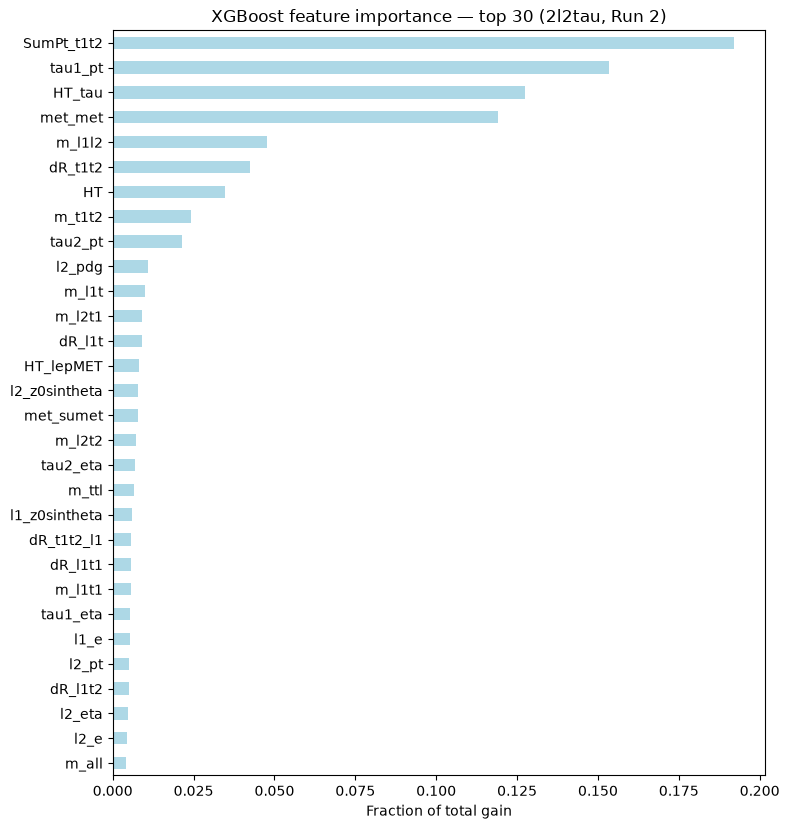

In [15]:
# ---- Baseline XGBoost + feature importance (Run 2) --------------------------
PLOTS_DIR_R2 = BASE_DIR_R2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)

model_r2, auc_train_r2, auc_val_r2 = train_xgb_baseline(
    X_train_r2, y_train_r2, w_train_r2, X_val_r2, y_val_r2, w_val_r2, label="Run2 baseline"
)

imp_r2 = get_importance(model_r2, features_r2)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 2):")
print(imp_r2[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r2['total_gain'] == 0).sum()} / {len(features_r2)}")

plot_importance_bar(imp_r2, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (2l2tau, Run 2)",
                     save_path=PLOTS_DIR_R2 / "Run2BeforeCorrelation.png")


Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2CorrelationTop30.png


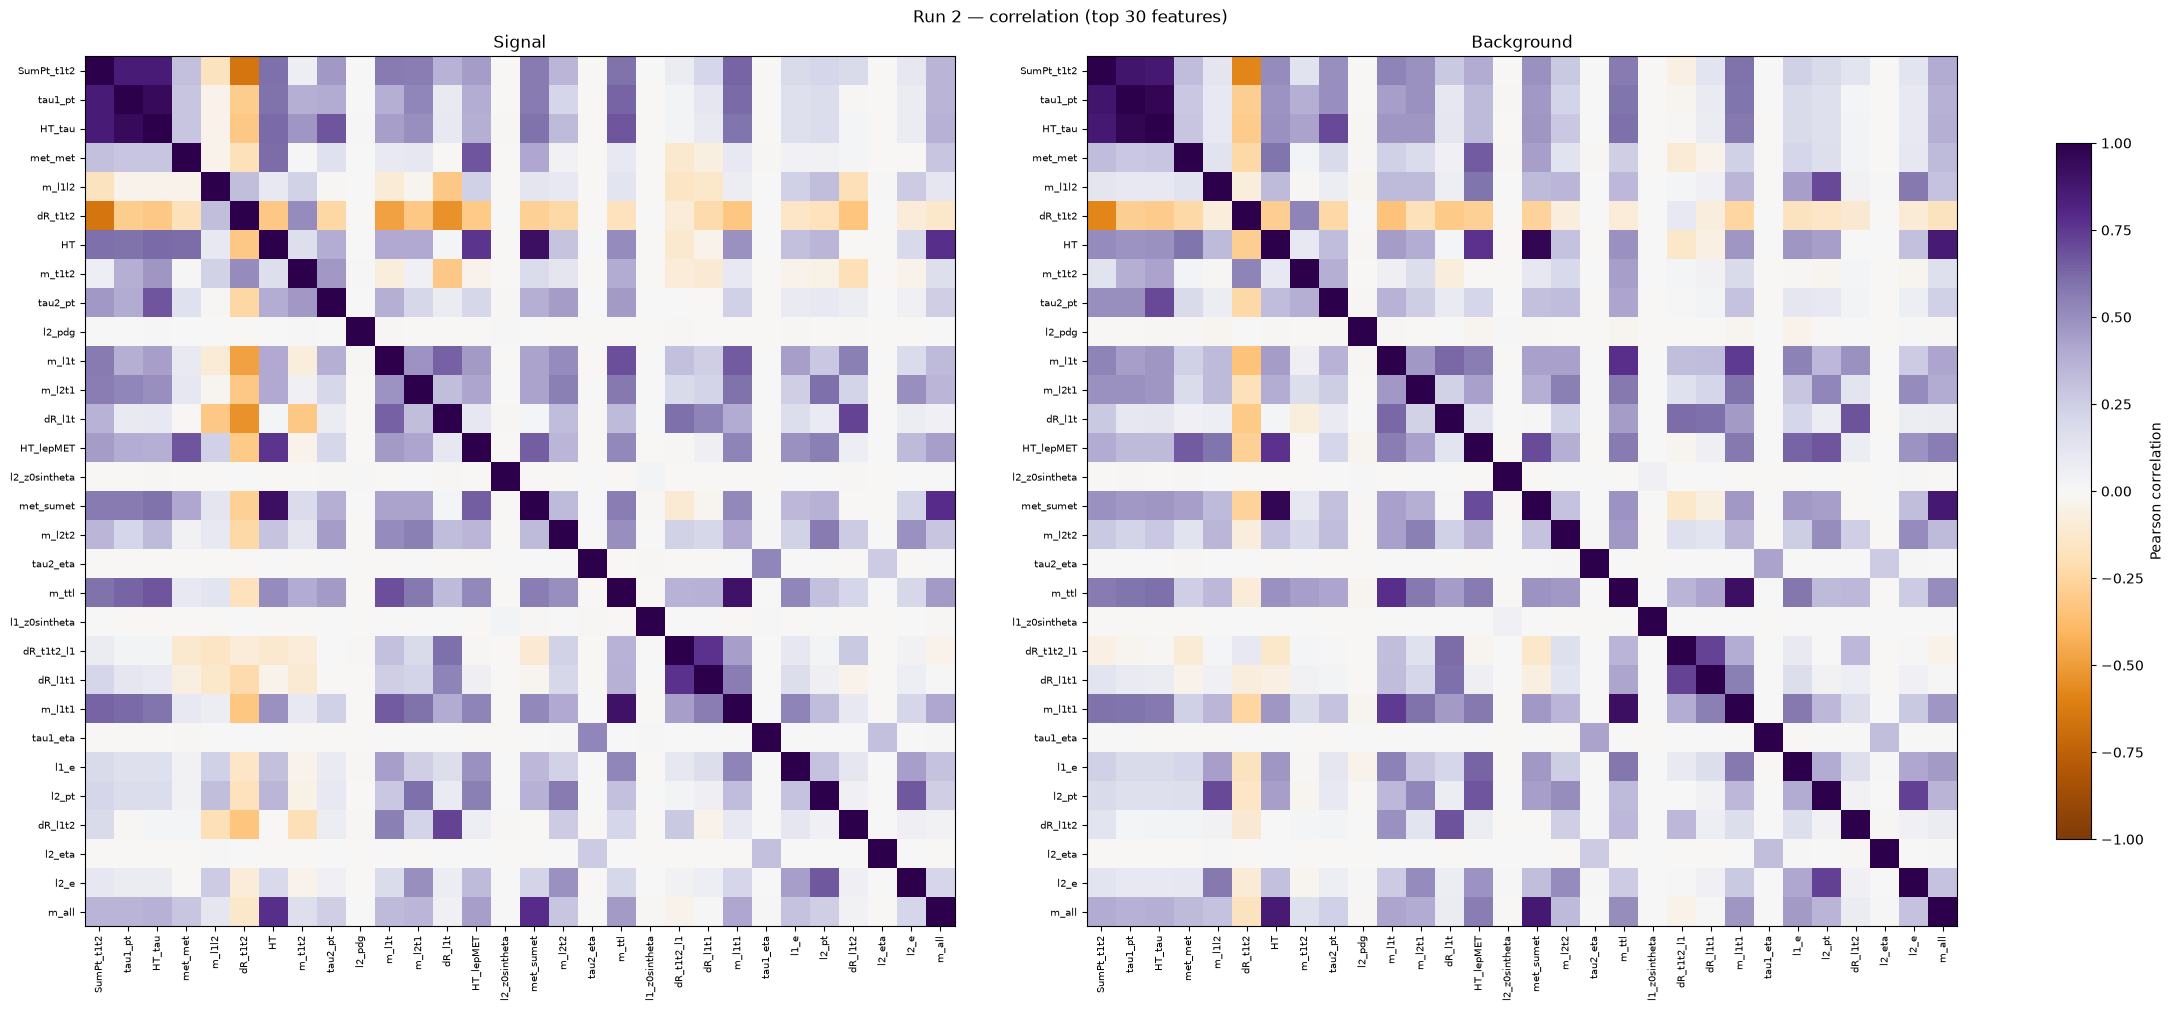

Pairs with |corr| > 0.50 (signal):
tau1_pt     HT_tau       0.945
HT          met_sumet    0.922
m_ttl       m_l1t1       0.906
SumPt_t1t2  tau1_pt      0.858
            HT_tau       0.856
met_sumet   m_all        0.782
HT          m_all        0.780
dR_t1t2_l1  dR_l1t1      0.772
HT          HT_lepMET    0.760
dR_l1t      dR_l1t2      0.720
m_l1t       m_ttl        0.695
met_met     HT_lepMET    0.679
HT_tau      tau2_pt      0.675
            m_ttl        0.674
l2_pt       l2_e         0.670
m_l1t       m_l1t1       0.659
HT_lepMET   met_sumet    0.653
SumPt_t1t2  dR_t1t2      0.650
m_l1t       dR_l1t       0.645
SumPt_t1t2  m_l1t1       0.635
tau1_pt     m_ttl        0.634
            m_l1t1       0.623
HT_tau      HT           0.621
met_met     HT           0.613
m_l2t1      l2_pt        0.608
SumPt_t1t2  HT           0.606
dR_l1t      dR_t1t2_l1   0.605
tau1_pt     HT           0.600
m_l2t1      m_l1t1       0.596
SumPt_t1t2  m_ttl        0.594
HT_tau      met_sumet    0.594
    

In [16]:
# ---- Correlation of the top features (Run 2) --------------------------------
# Pearson correlation among the TOP_N_IMPORTANCE most important features,
# separately for signal and background (correlations genuinely differ between
# the two by physics).

top_feats_r2 = imp_r2.index[:TOP_N_IMPORTANCE].tolist()
corrs_r2 = grouped_correlations(data_r2, top_feats_r2, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_r2[1], corrs_r2[0]], ["Signal", "Background"], top_feats_r2,
    suptitle=f"Run 2 — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r2[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r2[0]).to_string())


In [17]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 2) ------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.
corr_max_r2 = corrs_r2[1].abs().combine(corrs_r2[0].abs(), np.maximum)
PRUNED_FEATURES_R2, dropped_r2 = prune_correlated(top_feats_r2, corr_max_r2, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. SumPt_t1t2
   2. met_met
   3. m_l1l2
   4. dR_t1t2
   5. HT
   6. m_t1t2
   7. tau2_pt
   8. l2_pdg
   9. m_l1t
  10. m_l2t1
  11. dR_l1t
  12. l2_z0sintheta
  13. m_l2t2
  14. tau2_eta
  15. l1_z0sintheta
  16. dR_t1t2_l1
  17. m_l1t1
  18. tau1_eta
  19. l1_e
  20. l2_pt

Dropped 6 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with SumPt_t1t2      (|corr| = 0.884)
  HT_tau          -> redundant with SumPt_t1t2      (|corr| = 0.871)
  HT_lepMET       -> redundant with HT              (|corr| = 0.766)
  met_sumet       -> redundant with HT              (|corr| = 0.967)
  m_ttl           -> redundant with m_l1t           (|corr| = 0.780)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.772)


[Run2 pruned] signal weight scale factor: 3006.3
[0]	validation_0-logloss:0.65432	validation_0-auc:0.88789
[50]	validation_0-logloss:0.30888	validation_0-auc:0.96317
[100]	validation_0-logloss:0.31120	validation_0-auc:0.96507
[150]	validation_0-logloss:0.32028	validation_0-auc:0.96526
[194]	validation_0-logloss:0.32072	validation_0-auc:0.96552
[Run2 pruned] best_iteration=164 | weighted AUC: train=0.9916 val=0.9657

Comparison — full 79 features: val AUC = 0.9707 | pruned 20 features: val AUC = 0.9657
Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2AfterCorrelation.png


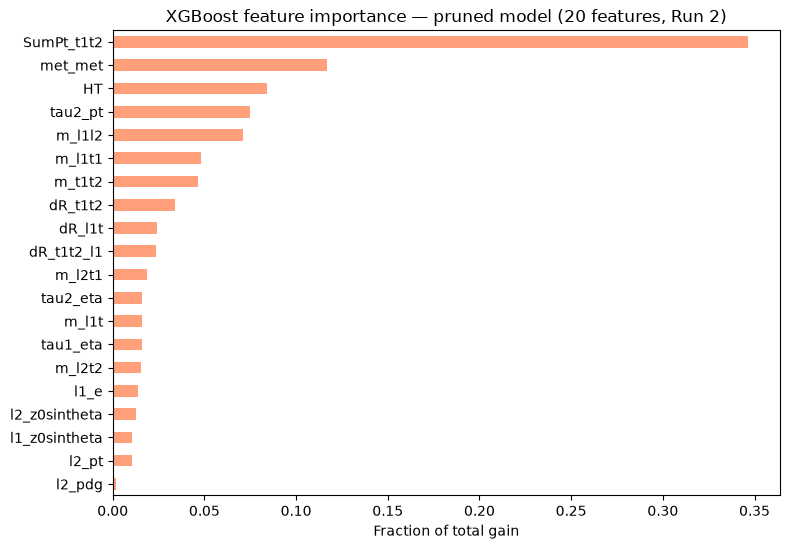

Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2CorrelationPruned.png


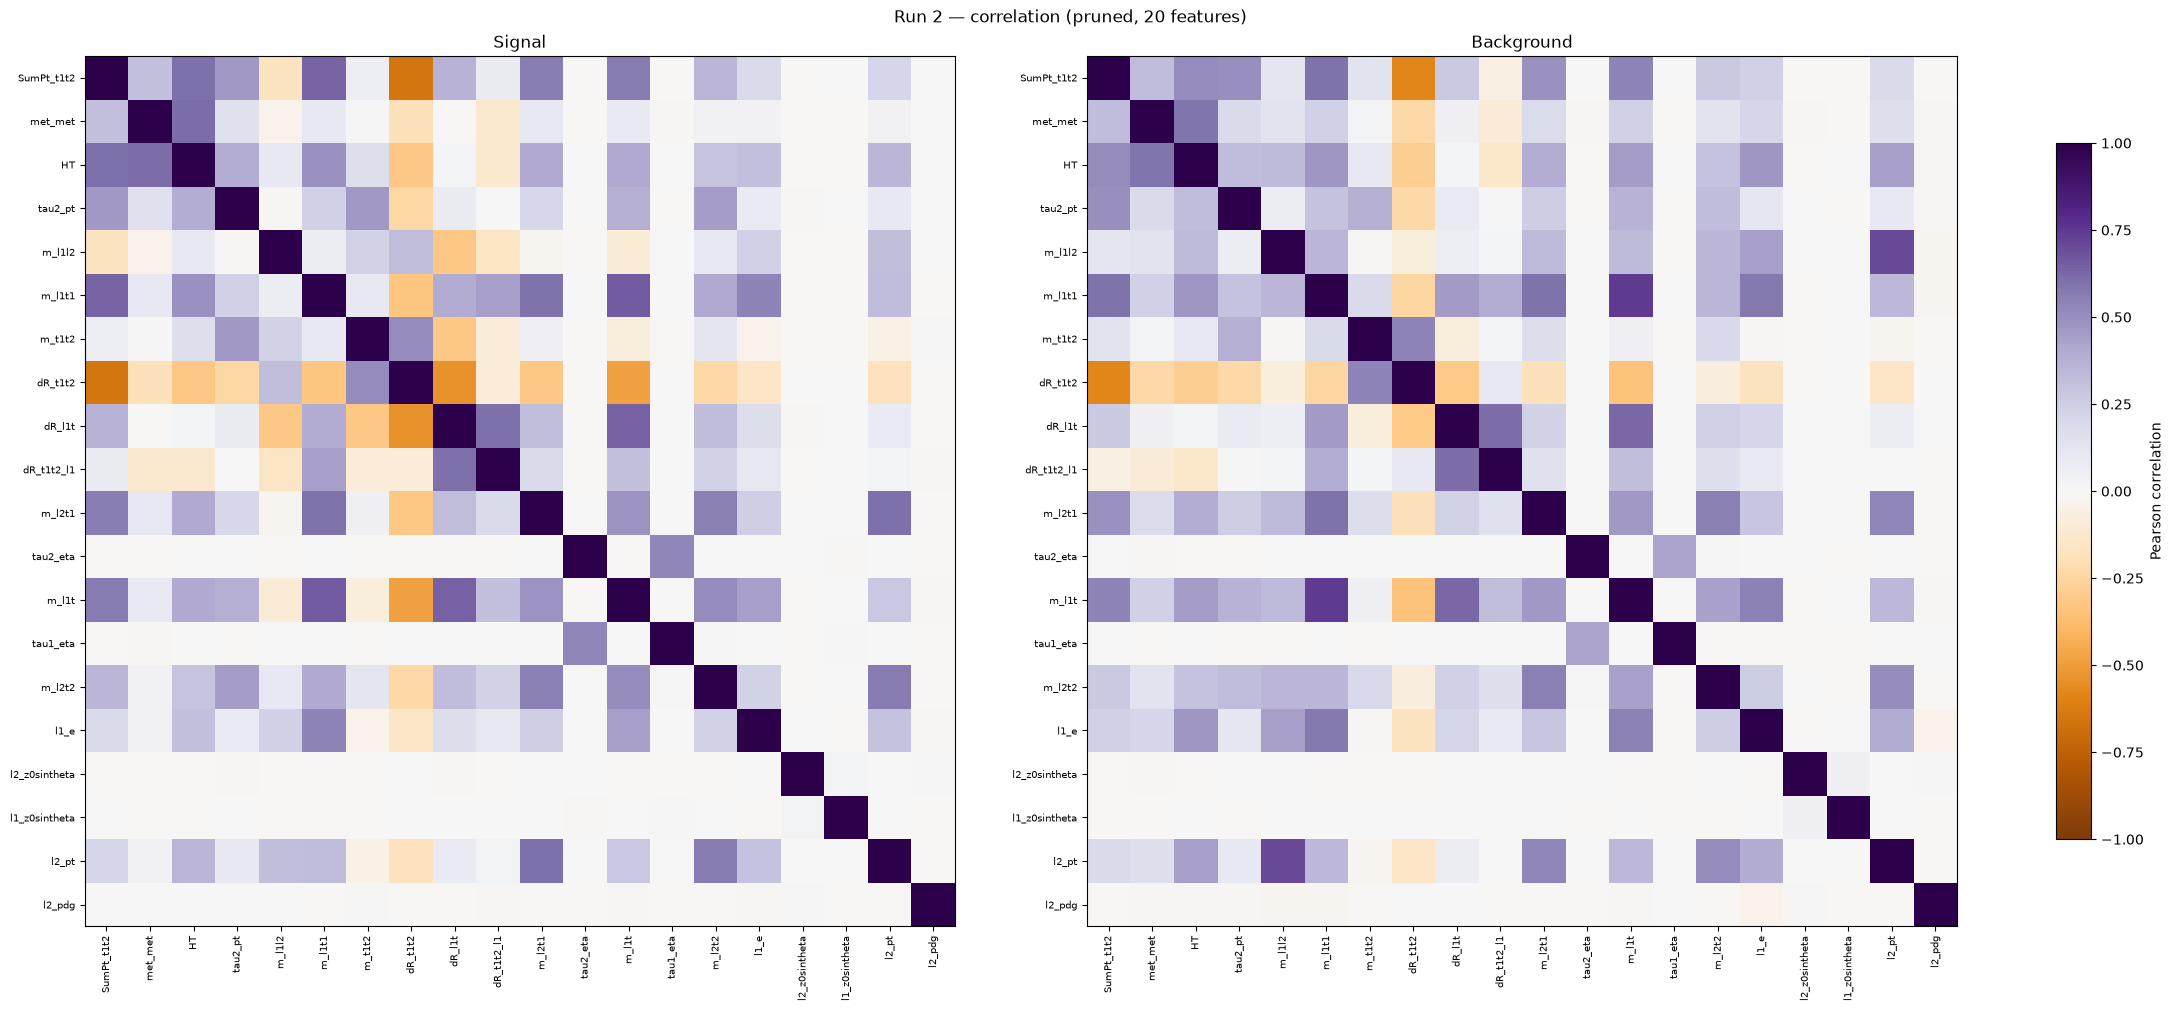

In [18]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 2) ------
model_r2_pruned, auc_train_r2_pruned, auc_val_r2_pruned = train_xgb_baseline(
    X_train_r2[PRUNED_FEATURES_R2], y_train_r2, w_train_r2,
    X_val_r2[PRUNED_FEATURES_R2], y_val_r2, w_val_r2, label="Run2 pruned",
)

imp_r2_pruned = get_importance(model_r2_pruned, PRUNED_FEATURES_R2)
print(f"\nComparison — full {len(features_r2)} features: val AUC = {auc_val_r2:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R2)} features: val AUC = {auc_val_r2_pruned:.4f}")

plot_importance_bar(
    imp_r2_pruned, top_n=len(PRUNED_FEATURES_R2),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R2)} features, Run 2)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R2 / "Run2AfterCorrelation.png",
)

pruned_top_feats_r2 = imp_r2_pruned.index.tolist()
pruned_corrs_r2 = grouped_correlations(data_r2, pruned_top_feats_r2, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r2[1], pruned_corrs_r2[0]], ["Signal", "Background"], pruned_top_feats_r2,
    suptitle=f"Run 2 — correlation (pruned, {len(pruned_top_feats_r2)} features)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationPruned.png",
)


In [19]:
# ---- Optuna hyperparameter search (Run 2) -----------------------------------
# Tune only on the Run-2 training partition, restricted to the decorrelated
# pruned feature set. X_val_r2 is never touched here, so it stays a clean
# holdout for the final tuned model below.

OPTUNA_FEATURES_R2 = PRUNED_FEATURES_R2.copy()

X_opt_r2 = X_train_r2[OPTUNA_FEATURES_R2].reset_index(drop=True)
y_opt_r2 = y_train_r2.reset_index(drop=True).to_numpy()
w_opt_r2 = np.abs(w_train_r2.reset_index(drop=True).to_numpy())

study_r2 = run_optuna_search(
    X_opt_r2, y_opt_r2, w_opt_r2,
    n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
    base_n_estimators=800, study_name="xgb_2l2tau_run2",
)


/tmp/ipykernel_42855/2307537205.py:74: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_2l2tau_run2] completed trials: 15
[xgb_2l2tau_run2] best mean CV AUC: 0.97223
[xgb_2l2tau_run2] mean best iteration: 760
[xgb_2l2tau_run2] fold AUCs: [0.9733114389904949, 0.9711884406776116, 0.9721815432933243]
[xgb_2l2tau_run2] best parameters:
    learning_rate: 0.022849791233739047
    max_depth: 7
    min_child_weight: 14.447050502654806
    subsample: 0.8885613366224214
    colsample_bytree: 0.6133712334210111
    gamma: 0.36701350861767157
    reg_alpha: 0.3591735149938728
    reg_lambda: 8.574063030677097


[Run2 tuned] features=20 trees=760
[Run2 tuned] weighted AUC: train=0.99117 val(holdout)=0.96630 (unweighted val=0.88581, overtrain gap=0.02487)
Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2OptunaDiagnostics.png


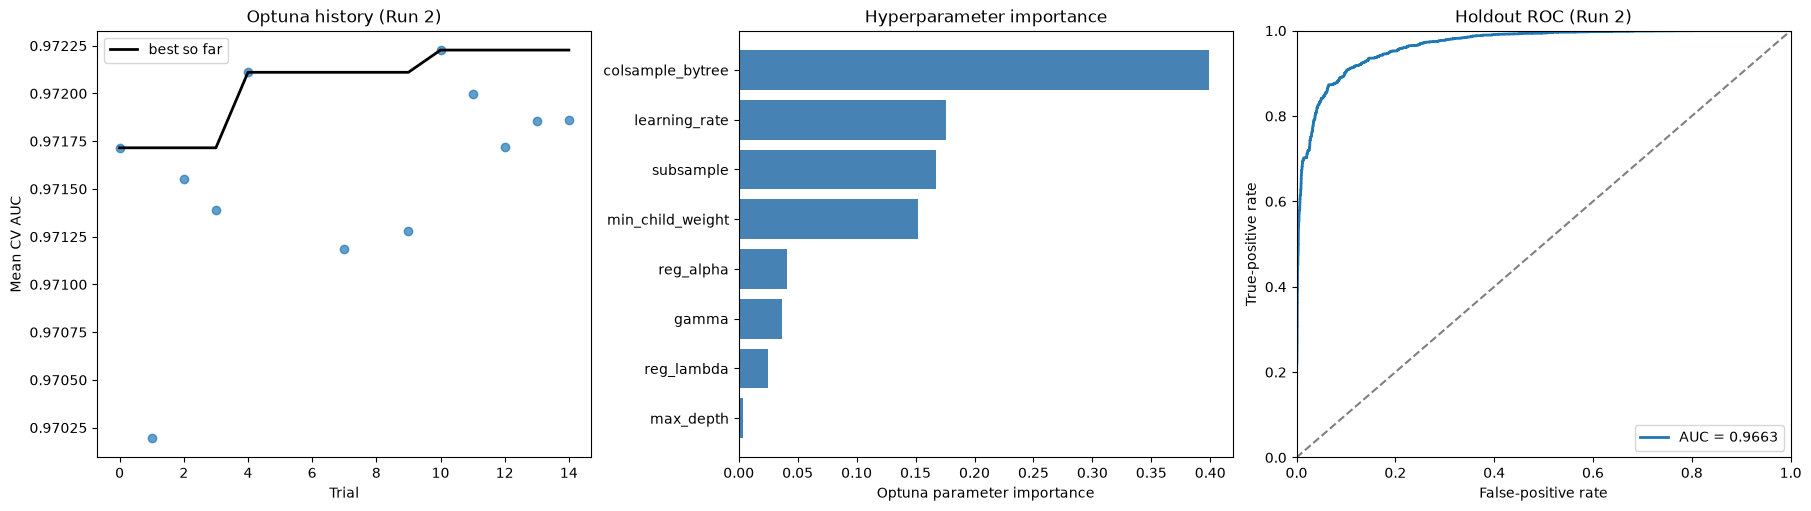

Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2AfterOptuna.png


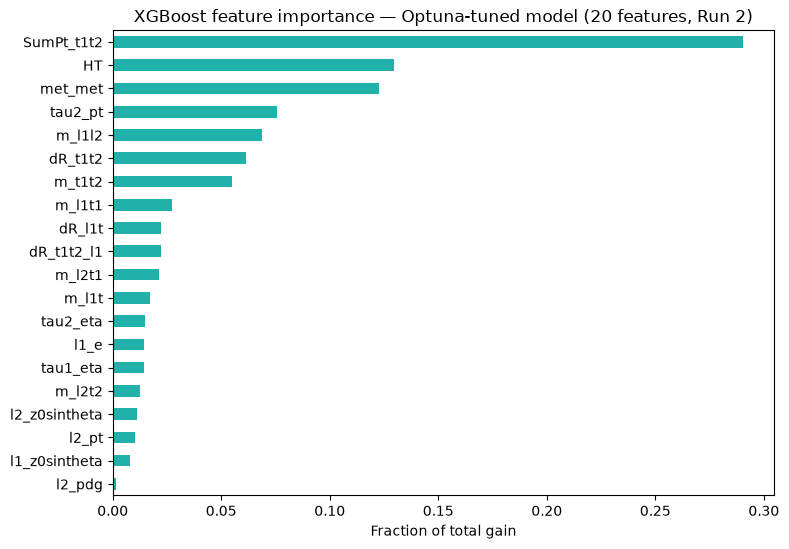

In [20]:
# ---- Final Optuna-tuned model + diagnostics (Run 2) -------------------------

final_model_r2, auc_train_opt_r2, auc_val_opt_r2, pred_val_r2, w_val_abs_r2 = train_final_tuned_model(
    study_r2, X_train_r2[OPTUNA_FEATURES_R2], y_train_r2, w_train_r2,
    X_val_r2[OPTUNA_FEATURES_R2], y_val_r2, w_val_r2, label="Run2 tuned",
)

plot_optuna_diagnostics(study_r2, y_val_r2, pred_val_r2, w_val_abs_r2, auc_val_opt_r2, title_suffix="(Run 2)",
                        save_path=PLOTS_DIR_R2 / "Run2OptunaDiagnostics.png")

final_imp_r2 = get_importance(final_model_r2, OPTUNA_FEATURES_R2)

plot_importance_bar(
    final_imp_r2, top_n=len(OPTUNA_FEATURES_R2),
    title=f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES_R2)} features, Run 2)",
    color="lightseagreen",
    save_path=PLOTS_DIR_R2 / "Run2AfterOptuna.png",
)


In [21]:
# ---- Persist the Run-2 final model + feature list ---------------------------
# Used by Section 6 (Run2 vs Run3 domain-shift check) to score events with the
# exact features the signal-vs-background BDT was trained on.
MODEL_PATH_R2 = BASE_DIR_R2 / "final_model_run2.json"
FEATURES_PATH_R2 = BASE_DIR_R2 / "optuna_features_run2.json"

final_model_r2.save_model(MODEL_PATH_R2)
with open(FEATURES_PATH_R2, "w") as f:
    json.dump(OPTUNA_FEATURES_R2, f)

print(f"Saved Run-2 final model                   -> {MODEL_PATH_R2}")
print(f"Saved Run-2 feature list (n={len(OPTUNA_FEATURES_R2)}) -> {FEATURES_PATH_R2}")


Saved Run-2 final model                   -> PPSSP_2026/2l2tau/run2/final_model_run2.json
Saved Run-2 feature list (n=20) -> PPSSP_2026/2l2tau/run2/optuna_features_run2.json


## 4. Run 3 — Solo Track

Identical procedure to Section 3, independently on **Run 3 only** (separate
feature-discovery pass too, in case branches differ slightly between
campaigns).


In [22]:
# ---- Load & clean (Run 3) ---------------------------------------------------
features_r3 = discover_common_features([BASE_DIR_R3])
data_r3 = load_run_data(BASE_DIR_R3, run_label=3, features=features_r3)
data_r3, features_r3 = clean_data(data_r3, features_r3)
data_r3.head()


85 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)
Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection


Run 3 Diboson     :    82336 events after preselection
Run 3 Zjets       :    12919 events after preselection
Run 3 Wjets       :       51 events after preselection
Run 3 ttbar       :     3276 events after preselection
Run 3 tops        :    11065 events after preselection
Run 3 SingleH     :     3240 events after preselection
Run 3 Vgamma      :     2366 events after preselection
Run 3 VVV         :    13941 events after preselection
Dropped 6 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id']

79 final features
Total: 229542 events | signal = 100348 | background = 129194
Yield (w_phys): signal = 0.49 | background = 2126.09


,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau1_pt,tau2_eta,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,"369,540.469","341,893.219","199,470.562","80,148.562","107,795.812","62,274.102","109,618.320","21,708.609","32,057.354",1.326,...,"37,569.562",-0.976,-2.642,"24,704.539",0.001,0.028,0.000,1,signal_ggF,3
1,"185,936.312","146,177.109",0.000,"102,864.719","142,623.922","43,312.387","61,778.746","61,778.746","10,123.177",NaN,...,"22,157.031",-0.538,1.548,"21,155.355",0.001,-0.039,-0.000,1,signal_ggF,3
2,"193,755.312","121,575.641",0.000,"33,224.691","105,404.359","88,350.953","22,594.273","22,594.273","20,340.336",NaN,...,"51,549.520",1.802,0.342,"36,801.430",0.001,0.021,0.000,1,signal_ggF,3
3,"487,495.656","472,277.188","318,791.438","106,009.797","121,228.250","47,475.973","159,514.734","102,968.805","41,378.273",2.810,...,"25,683.918",-0.239,-2.835,"21,792.055",0.001,0.041,0.000,1,signal_ggF,3
4,"182,144.703","142,537.812","26,865.521","58,703.934","98,310.812","56,968.367","16,995.748","16,995.748","40,460.621",NaN,...,"35,258.930",-0.581,1.209,"21,709.438",0.001,0.040,0.000,1,signal_ggF,3


In [23]:
# ---- Yields / S over B (Run 3) ----------------------------------------------
yields_r3 = compute_yields(data_r3, BASE_DIR_R3)


   process   N_mc  yield_skim  N_presel     yield  pct_of_bkg  frac_neg
     Zjets  73738   8,229.803     12919 1,658.799      78.021     0.155
    Vgamma   4583     351.179      2366   233.058      10.962     0.081
     ttbar  10094     312.479      3276    99.227       4.667     0.003
   Diboson 453418     390.878     82336    81.396       3.828     0.091
   SingleH  20918      96.632      3240    56.860       2.674     0.005
      tops 133506      49.968     11065     9.522       0.448     0.287
       VVV  43855       4.241     13941     2.340       0.110     0.010
     Wjets     96      -1.639        51   -15.108      -0.711     0.157
signal_ggF 137429       0.684     96909     0.472         NaN     0.061
signal_VBF   4861       0.028      3439     0.020         NaN     0.002

Total background (presel): 2,126.095
Total signal     (presel): 0.491
S/B       = 2.31e-04
S/sqrt(B) = 0.0107


In [24]:
# ---- Train / validation split (Run 3) ---------------------------------------

(X_train_r3, y_train_r3, w_train_r3,
 X_val_r3, y_val_r3, w_val_r3,
 train_df_r3, val_df_r3) = make_train_val_split(data_r3, features_r3)

# ---- Persist the split to ROOT files ----------------------------------------

SPLIT_DIR_R3 = BASE_DIR_R3 / "splits"
SPLIT_DIR_R3.mkdir(parents=True, exist_ok=True)
TRAIN_ROOT_R3 = SPLIT_DIR_R3 / "train.root"
VAL_ROOT_R3 = SPLIT_DIR_R3 / "val.root"

with uproot.recreate(TRAIN_ROOT_R3) as f:
    f["tree"] = train_df_r3.reset_index(drop=True)
with uproot.recreate(VAL_ROOT_R3) as f:
    f["tree"] = val_df_r3.reset_index(drop=True)

print(f"Wrote {len(train_df_r3)} training events   -> {TRAIN_ROOT_R3}")
print(f"Wrote {len(val_df_r3)} validation events -> {VAL_ROOT_R3}")


Train: 183633 events | signal = 80278 | background = 103355
Val:   45909 events | signal = 20070 | background = 25839
Wrote 183633 training events   -> PPSSP_2026/2l2tau/run3/splits/train.root
Wrote 45909 validation events -> PPSSP_2026/2l2tau/run3/splits/val.root


[Run3 baseline] signal weight scale factor: 5351.7
[0]	validation_0-logloss:0.62994	validation_0-auc:0.94584
[50]	validation_0-logloss:0.23392	validation_0-auc:0.97211
[100]	validation_0-logloss:0.22354	validation_0-auc:0.97700
[150]	validation_0-logloss:0.22398	validation_0-auc:0.97785
[200]	validation_0-logloss:0.22477	validation_0-auc:0.97853
[250]	validation_0-logloss:0.22456	validation_0-auc:0.97901
[275]	validation_0-logloss:0.22618	validation_0-auc:0.97900
[Run3 baseline] best_iteration=245 | weighted AUC: train=0.9947 val=0.9790

Top 30 features by total gain (Run 3):
               total_gain  gain_frac  weight
HT_tau        411,916.938      0.419 373.000
met_met        79,085.492      0.081 479.000
tau1_pt        73,633.367      0.075 287.000
SumPt_t1t2     48,821.805      0.050 363.000
m_l1l2         40,933.676      0.042 633.000
HT             38,402.207      0.039 245.000
dR_t1t2        33,741.086      0.034 408.000
m_t1t2         18,606.648      0.019 423.000
l2_pdg      

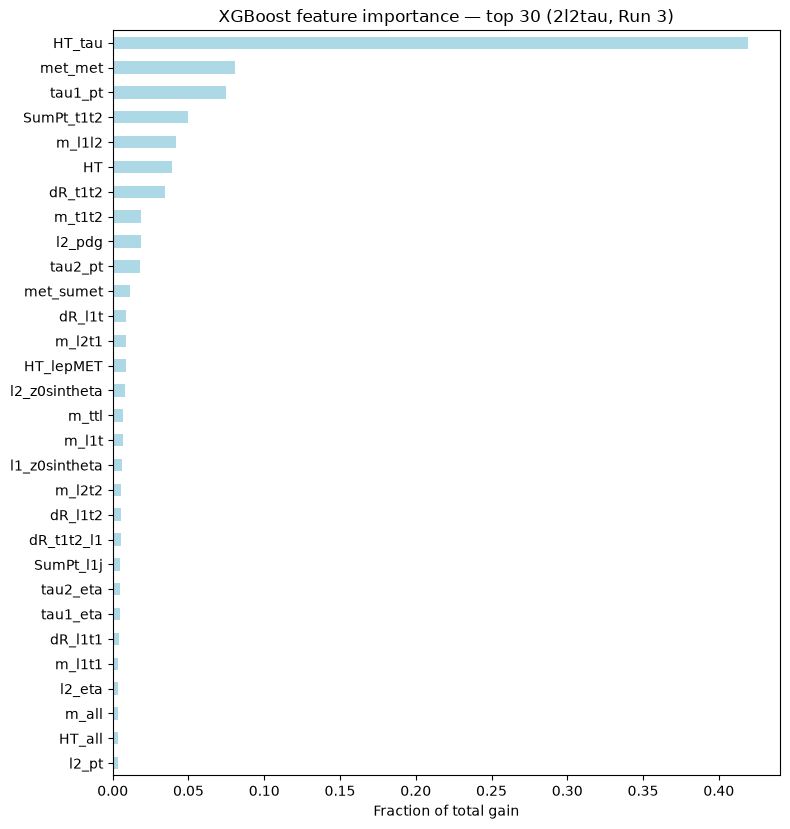

In [25]:
# ---- Baseline XGBoost + feature importance (Run 3) --------------------------

PLOTS_DIR_R3 = BASE_DIR_R3 / "plots"
PLOTS_DIR_R3.mkdir(parents=True, exist_ok=True)

model_r3, auc_train_r3, auc_val_r3 = train_xgb_baseline(
    X_train_r3, y_train_r3, w_train_r3, X_val_r3, y_val_r3, w_val_r3, label="Run3 baseline"
)

imp_r3 = get_importance(model_r3, features_r3)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 3):")
print(imp_r3[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r3['total_gain'] == 0).sum()} / {len(features_r3)}")

plot_importance_bar(imp_r3, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (2l2tau, Run 3)",
                     save_path=PLOTS_DIR_R3 / "Run3BeforeCorrelation.png")


Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3CorrelationTop30.png


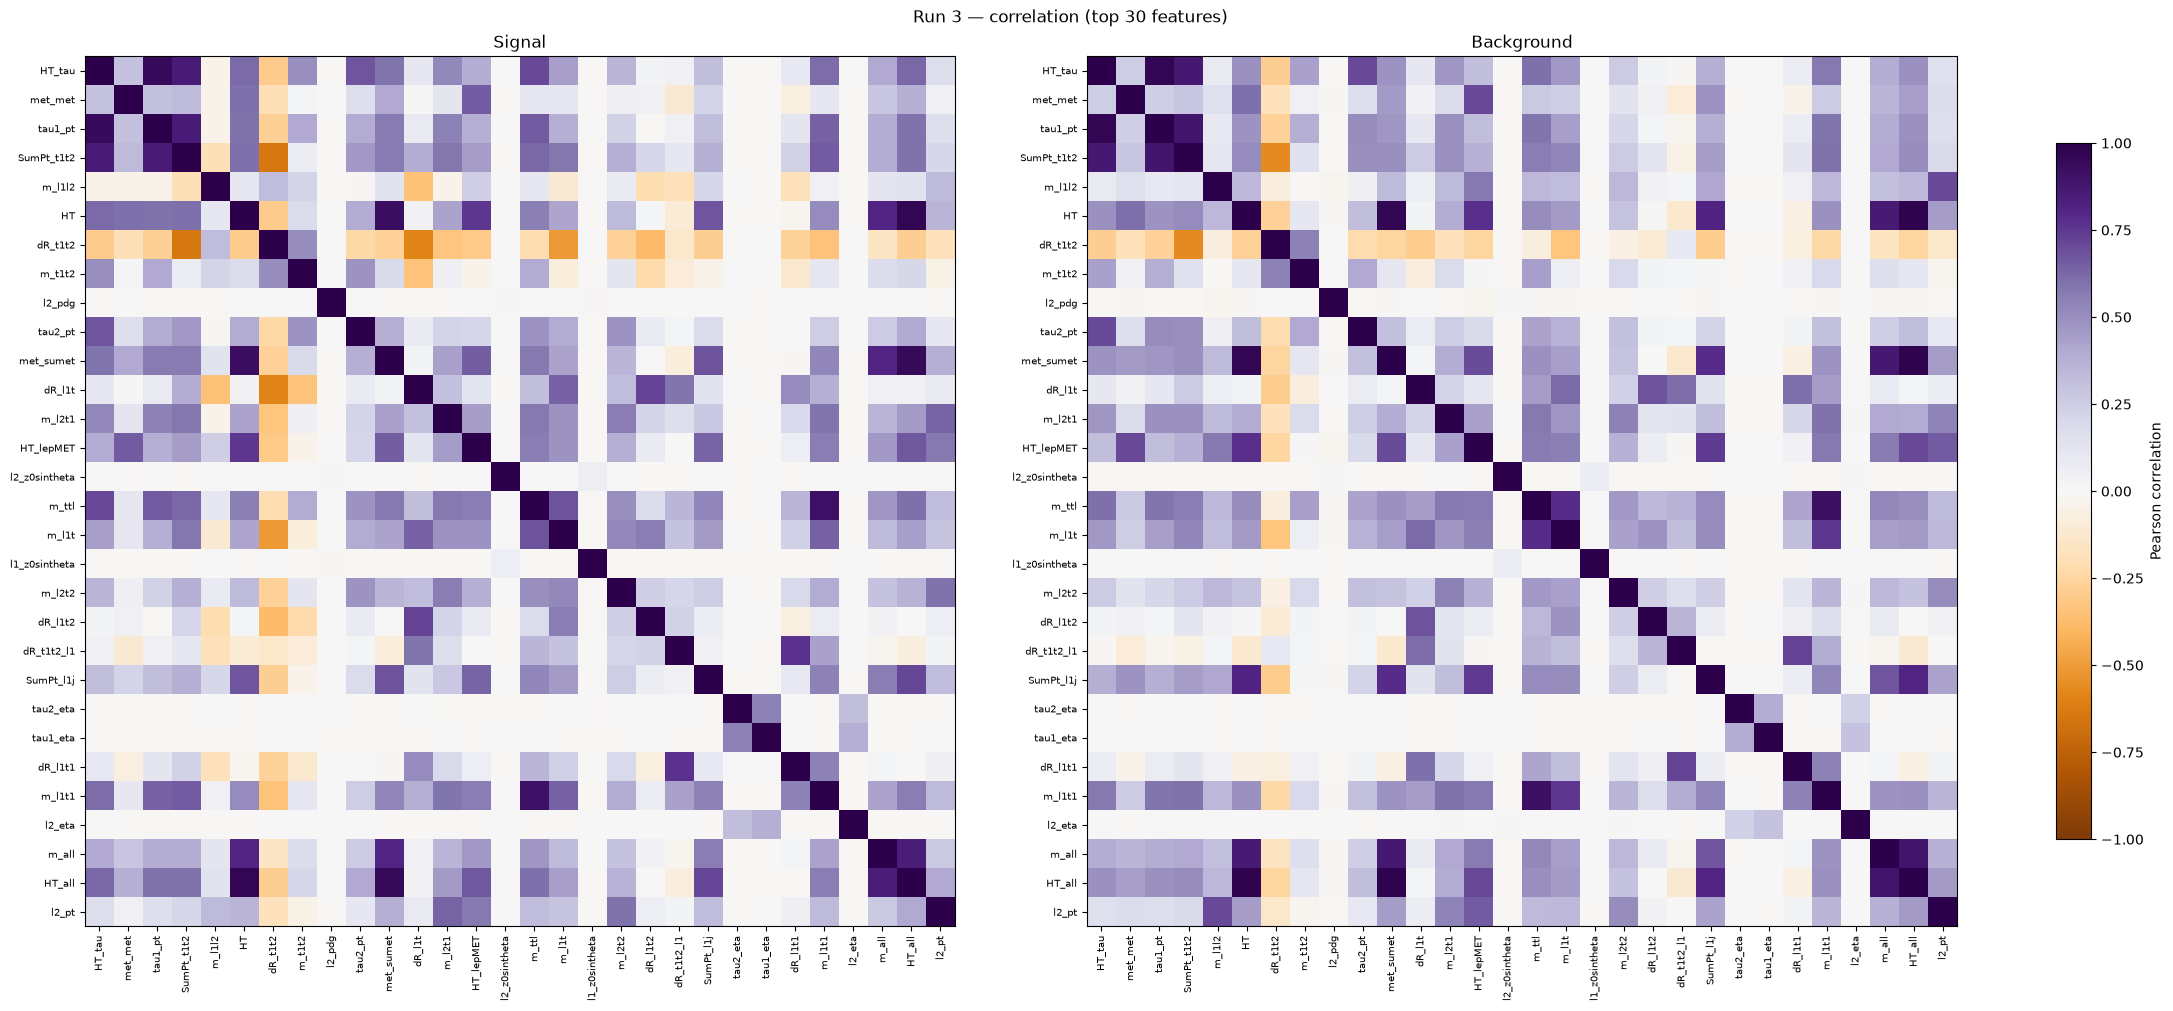

Pairs with |corr| > 0.50 (signal):
HT          HT_all       0.966
met_sumet   HT_all       0.949
HT_tau      tau1_pt      0.944
HT          met_sumet    0.927
m_ttl       m_l1t1       0.908
tau1_pt     SumPt_t1t2   0.856
HT_tau      SumPt_t1t2   0.856
m_all       HT_all       0.846
met_sumet   m_all        0.810
HT          m_all        0.807
dR_t1t2_l1  dR_l1t1      0.771
HT          HT_lepMET    0.758
dR_l1t      dR_l1t2      0.722
SumPt_l1j   HT_all       0.716
HT_tau      m_ttl        0.705
m_ttl       m_l1t        0.687
met_sumet   SumPt_l1j    0.681
HT          SumPt_l1j    0.679
HT_tau      tau2_pt      0.673
HT_lepMET   HT_all       0.666
met_met     HT_lepMET    0.664
tau1_pt     m_ttl        0.662
SumPt_t1t2  m_l1t1       0.662
met_sumet   HT_lepMET    0.653
dR_l1t      m_l1t        0.648
tau1_pt     m_l1t1       0.647
m_l1t       m_l1t1       0.645
SumPt_t1t2  dR_t1t2      0.642
HT_lepMET   SumPt_l1j    0.637
m_l2t1      l2_pt        0.635
HT_tau      HT_all       0.627
SumP

In [26]:
# ---- Correlation of the top features (Run 3) --------------------------------
top_feats_r3 = imp_r3.index[:TOP_N_IMPORTANCE].tolist()
corrs_r3 = grouped_correlations(data_r3, top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_r3[1], corrs_r3[0]], ["Signal", "Background"], top_feats_r3,
    suptitle=f"Run 3 — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r3[0]).to_string())


In [27]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 3) ------------
corr_max_r3 = corrs_r3[1].abs().combine(corrs_r3[0].abs(), np.maximum)
PRUNED_FEATURES_R3, dropped_r3 = prune_correlated(top_feats_r3, corr_max_r3, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. met_met
   3. m_l1l2
   4. HT
   5. dR_t1t2
   6. m_t1t2
   7. l2_pdg
   8. tau2_pt
   9. dR_l1t
  10. m_l2t1
  11. l2_z0sintheta
  12. m_ttl
  13. l1_z0sintheta
  14. m_l2t2
  15. dR_l1t2
  16. dR_t1t2_l1
  17. tau2_eta
  18. tau1_eta
  19. l2_eta
  20. l2_pt

Dropped 10 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.966)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.870)
  met_sumet       -> redundant with HT              (|corr| = 0.963)
  HT_lepMET       -> redundant with HT              (|corr| = 0.777)
  m_l1t           -> redundant with m_ttl           (|corr| = 0.784)
  SumPt_l1j       -> redundant with HT              (|corr| = 0.817)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.771)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.919)
  m_all           -> redundant wi

[Run3 pruned] signal weight scale factor: 5351.7
[0]	validation_0-logloss:0.64961	validation_0-auc:0.88884
[50]	validation_0-logloss:0.24327	validation_0-auc:0.96977
[100]	validation_0-logloss:0.24724	validation_0-auc:0.97113
[150]	validation_0-logloss:0.25190	validation_0-auc:0.97143
[188]	validation_0-logloss:0.25783	validation_0-auc:0.97131


[Run3 pruned] best_iteration=158 | weighted AUC: train=0.9894 val=0.9716

Comparison — full 79 features: val AUC = 0.9790 | pruned 20 features: val AUC = 0.9716
Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3AfterCorrelation.png


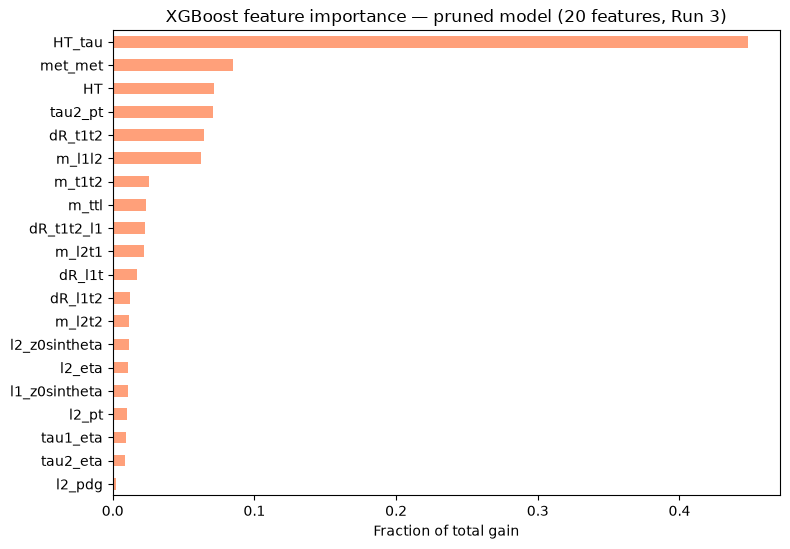

Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3CorrelationPruned.png


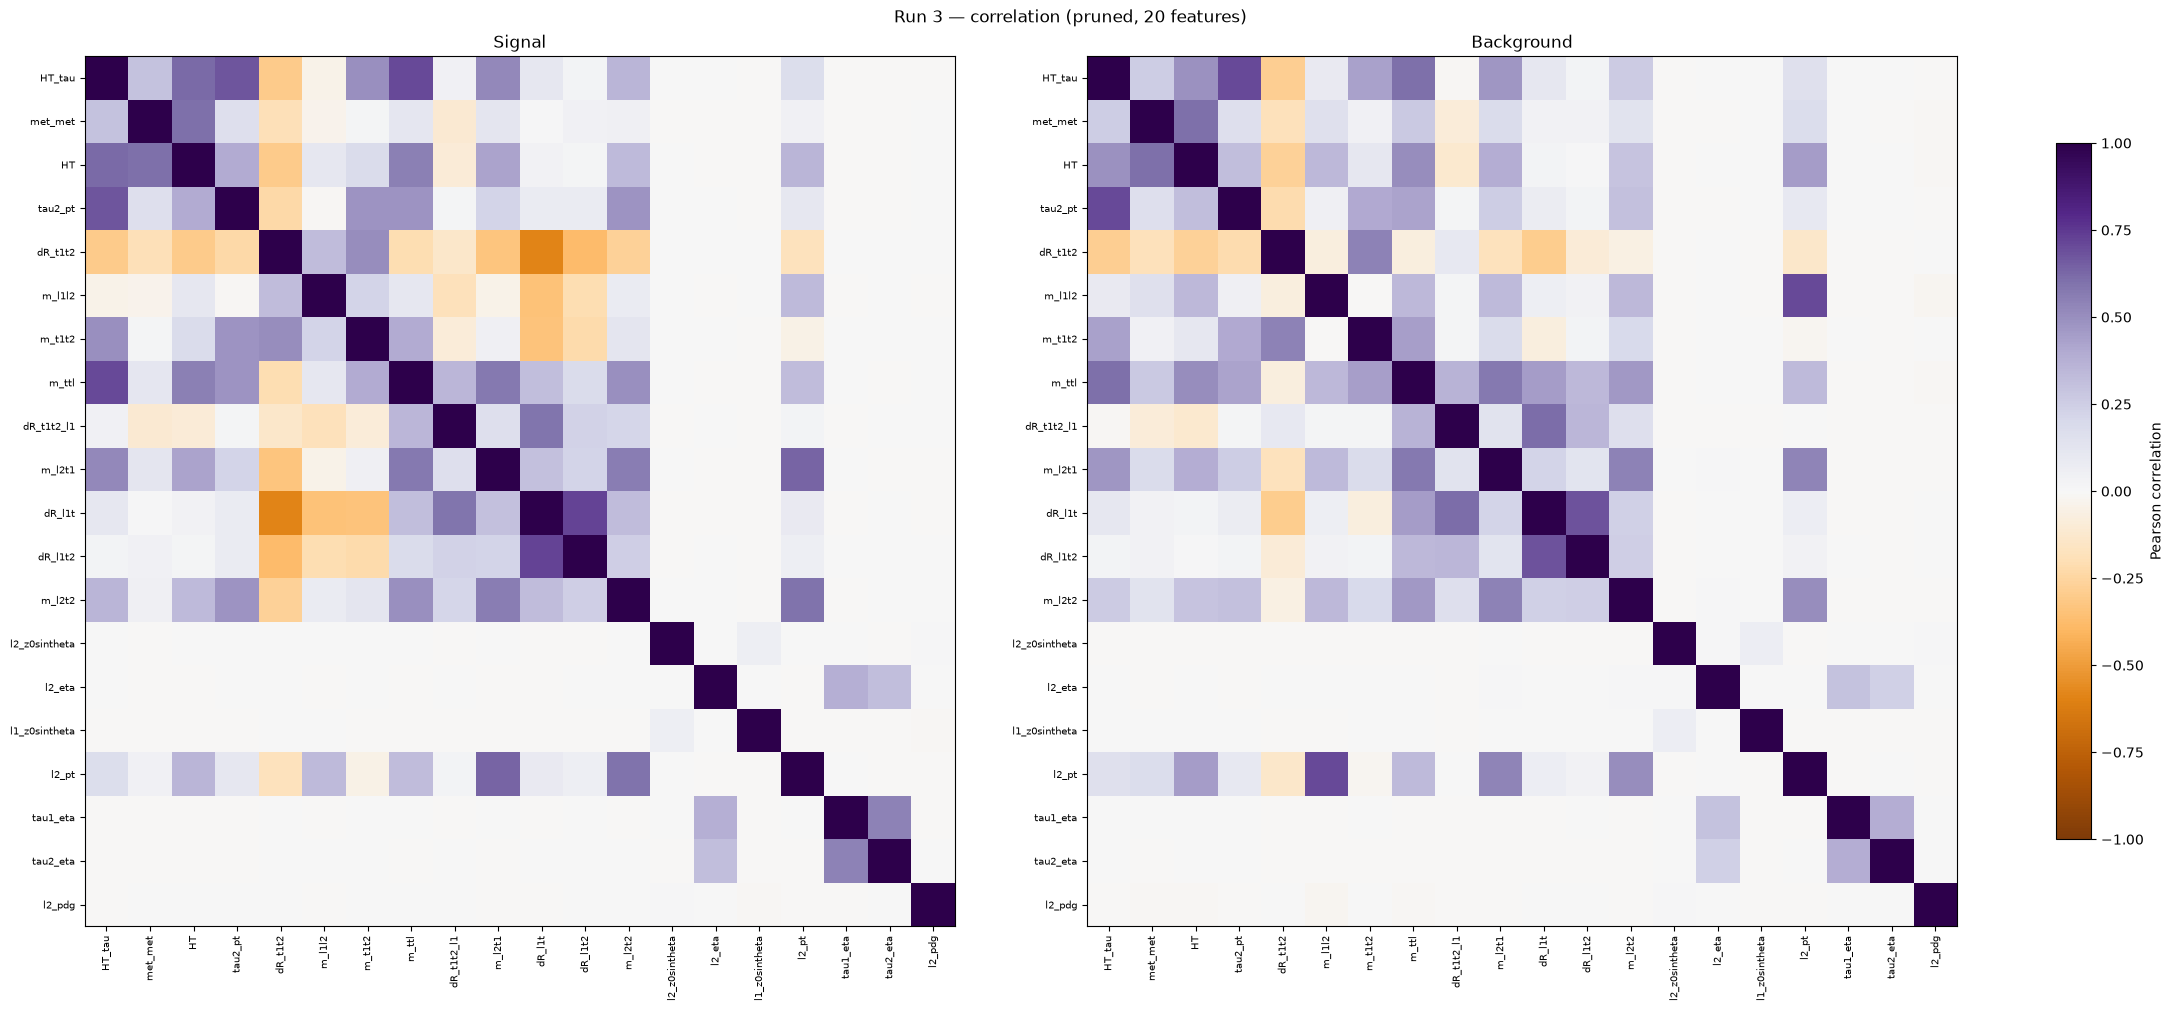

In [28]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 3) ------
model_r3_pruned, auc_train_r3_pruned, auc_val_r3_pruned = train_xgb_baseline(
    X_train_r3[PRUNED_FEATURES_R3], y_train_r3, w_train_r3,
    X_val_r3[PRUNED_FEATURES_R3], y_val_r3, w_val_r3, label="Run3 pruned",
)

imp_r3_pruned = get_importance(model_r3_pruned, PRUNED_FEATURES_R3)
print(f"\nComparison — full {len(features_r3)} features: val AUC = {auc_val_r3:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R3)} features: val AUC = {auc_val_r3_pruned:.4f}")

plot_importance_bar(
    imp_r3_pruned, top_n=len(PRUNED_FEATURES_R3),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R3)} features, Run 3)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R3 / "Run3AfterCorrelation.png",
)

pruned_top_feats_r3 = imp_r3_pruned.index.tolist()
pruned_corrs_r3 = grouped_correlations(data_r3, pruned_top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r3[1], pruned_corrs_r3[0]], ["Signal", "Background"], pruned_top_feats_r3,
    suptitle=f"Run 3 — correlation (pruned, {len(pruned_top_feats_r3)} features)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationPruned.png",
)


In [29]:
# ---- Optuna hyperparameter search (Run 3) -----------------------------------

OPTUNA_FEATURES_R3 = PRUNED_FEATURES_R3.copy()

X_opt_r3 = X_train_r3[OPTUNA_FEATURES_R3].reset_index(drop=True)
y_opt_r3 = y_train_r3.reset_index(drop=True).to_numpy()
w_opt_r3 = np.abs(w_train_r3.reset_index(drop=True).to_numpy())

study_r3 = run_optuna_search(
    X_opt_r3, y_opt_r3, w_opt_r3,
    n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
    base_n_estimators=800, study_name="xgb_2l2tau_run3",
)


/tmp/ipykernel_42855/2307537205.py:74: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_2l2tau_run3] completed trials: 15
[xgb_2l2tau_run3] best mean CV AUC: 0.97164
[xgb_2l2tau_run3] mean best iteration: 564
[xgb_2l2tau_run3] fold AUCs: [0.9722950372840516, 0.9707984854428441, 0.971838685783346]
[xgb_2l2tau_run3] best parameters:
    learning_rate: 0.03756400246176794
    max_depth: 7
    min_child_weight: 22.419927110960618
    subsample: 0.8326885153479879
    colsample_bytree: 0.7544925915069112
    gamma: 1.1477063390197093
    reg_alpha: 6.826786777384487
    reg_lambda: 0.14179933034238643


[Run3 tuned] features=20 trees=564
[Run3 tuned] weighted AUC: train=0.99142 val(holdout)=0.97282 (unweighted val=0.88776, overtrain gap=0.01860)
Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3OptunaDiagnostics.png


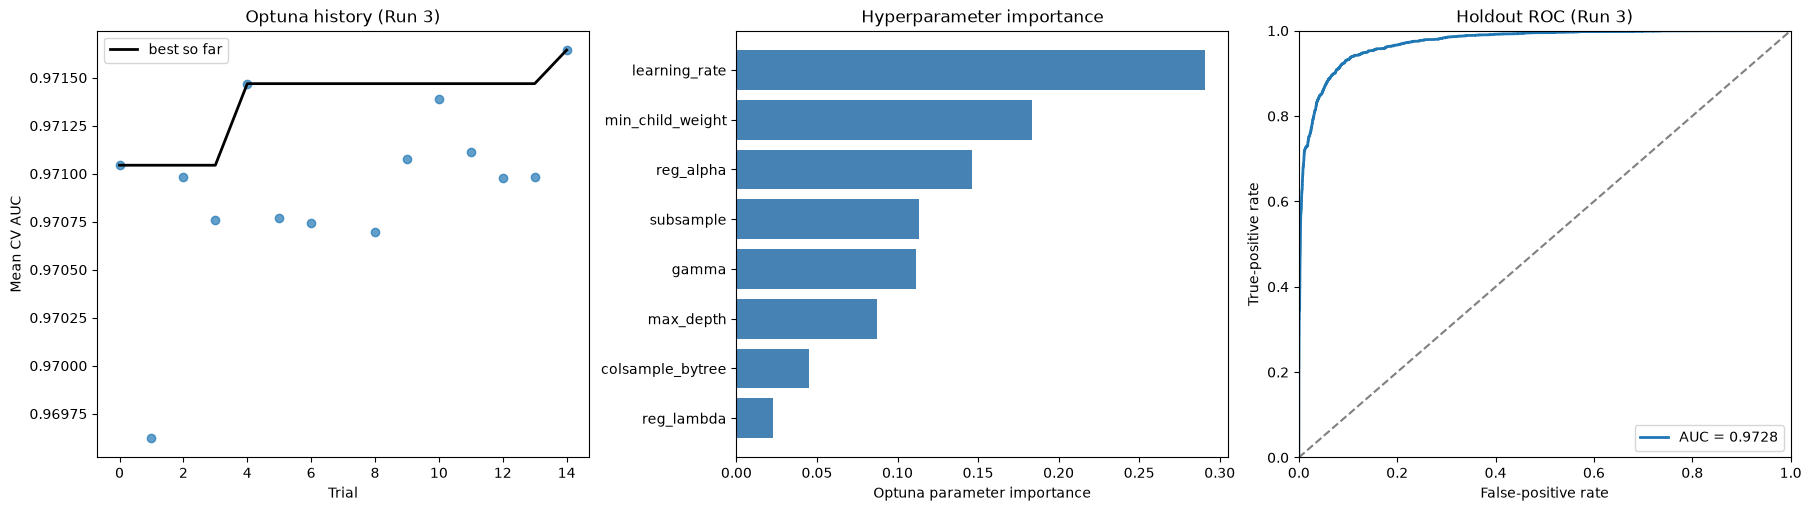

Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3AfterOptuna.png


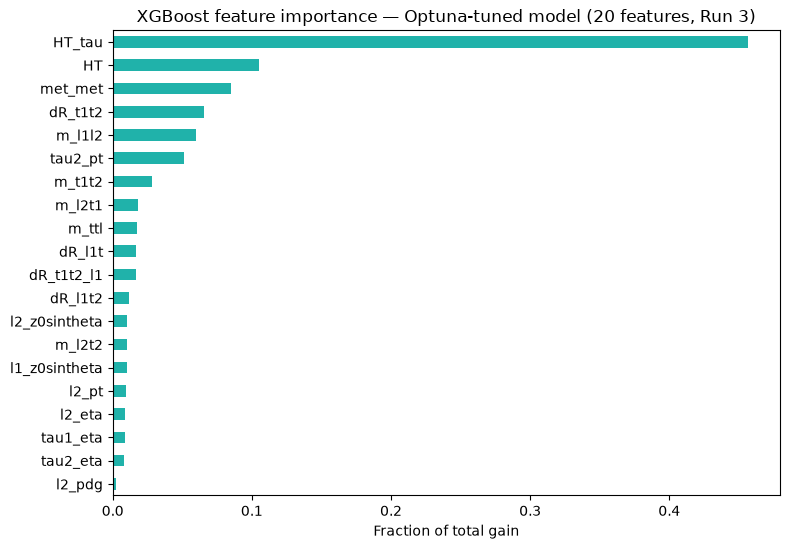

In [30]:
# ---- Final Optuna-tuned model + diagnostics (Run 3) -------------------------

final_model_r3, auc_train_opt_r3, auc_val_opt_r3, pred_val_r3, w_val_abs_r3 = train_final_tuned_model(
    study_r3, X_train_r3[OPTUNA_FEATURES_R3], y_train_r3, w_train_r3,
    X_val_r3[OPTUNA_FEATURES_R3], y_val_r3, w_val_r3, label="Run3 tuned",
)

plot_optuna_diagnostics(study_r3, y_val_r3, pred_val_r3, w_val_abs_r3, auc_val_opt_r3, title_suffix="(Run 3)",
                        save_path=PLOTS_DIR_R3 / "Run3OptunaDiagnostics.png")

final_imp_r3 = get_importance(final_model_r3, OPTUNA_FEATURES_R3)

plot_importance_bar(
    final_imp_r3, top_n=len(OPTUNA_FEATURES_R3),
    title=f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES_R3)} features, Run 3)",
    color="lightseagreen",
    save_path=PLOTS_DIR_R3 / "Run3AfterOptuna.png",
)


In [31]:
# ---- Persist the Run-3 final model + feature list ---------------------------
# Symmetric with Run 2's saved artifacts - also used by Section 6.

MODEL_PATH_R3 = BASE_DIR_R3 / "final_model_run3.json"
FEATURES_PATH_R3 = BASE_DIR_R3 / "optuna_features_run3.json"

final_model_r3.save_model(MODEL_PATH_R3)

with open(FEATURES_PATH_R3, "w") as f:
    json.dump(OPTUNA_FEATURES_R3, f)

print(f"Saved Run-3 final model                   -> {MODEL_PATH_R3}")
print(f"Saved Run-3 feature list (n={len(OPTUNA_FEATURES_R3)}) -> {FEATURES_PATH_R3}")


Saved Run-3 final model                   -> PPSSP_2026/2l2tau/run3/final_model_run3.json
Saved Run-3 feature list (n=20) -> PPSSP_2026/2l2tau/run3/optuna_features_run3.json


## 5. Run 2 + Run 3 — Combined Track

Chain (concatenate) **all** backgrounds and **both** signals from **both**
campaigns into a single training sample, then run the same pipeline. This
checks whether the feature-importance ranking learned on the combined sample
differs from the rankings learned separately in Sections 3/4, and gives the
most statistically powerful (most events) version of the BDT.

The feature list here is rebuilt from branches common to **all 20 files**
(10 processes × 2 runs) - a feature dropped in only one run must be dropped
everywhere once the runs are concatenated. An extra `run` column (2 or 3) is
kept as bookkeeping (never a training feature) so the Run2/Run3 mix in
train/val can be checked, and so the split can be stratified on `label` AND
`run` jointly.


In [32]:
# ---- Combined-track output paths --------------------------------------------
BASE_DIR_COMB = Path("PPSSP_2026/2l2tau/combined")
PLOTS_DIR_COMB = BASE_DIR_COMB / "plots"
PLOTS_DIR_COMB.mkdir(parents=True, exist_ok=True)

# ---- Load & clean (Combined Run2 + Run3) ------------------------------------
features_comb = discover_common_features([BASE_DIR_R2, BASE_DIR_R3])
data_comb = pd.concat(
    [
        load_run_data(BASE_DIR_R2, run_label=2, features=features_comb),
        load_run_data(BASE_DIR_R3, run_label=3, features=features_comb),
    ],
    ignore_index=True,
)
data_comb, features_comb = clean_data(data_comb, features_comb)

# Per-run yield breakdown - confirms both runs contribute comparable
# statistics to the chained sample (no run silently dominating the training).
for run_label in (2, 3):
    sub = data_comb[data_comb.run == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

data_comb.head()


85 candidate features (common to all 10 processes x 2 run(s) = 20 files, leakage-free)
Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection


Run 2 Diboson     :    36877 events after preselection
Run 2 Zjets       :     7746 events after preselection
Run 2 Wjets       :       67 events after preselection
Run 2 ttbar       :      331 events after preselection
Run 2 tops        :     3832 events after preselection
Run 2 SingleH     :     2946 events after preselection
Run 2 Vgamma      :     2019 events after preselection
Run 2 VVV         :     3593 events after preselection
Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection
Run 3 Diboson     :    82336 events after preselection
Run 3 Zjets       :    12919 events after preselection
Run 3 Wjets       :       51 events after preselection
Run 3 ttbar       :     3276 events after preselection
Run 3 tops        :    11065 events after preselection
Run 3 SingleH     :     3240 events after preselection
Run 3 Vgamma      :     2366 events after preselection
Run 3 VVV         :    13941 events after preselection
Dropped 6 

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau1_pt,tau2_eta,tau2_phi,tau2_pt,weight,weights,w_phys,label,process,run
0,"401,766.938","346,109.406","157,169.562","129,136.633","184,794.172","59,803.219","85,656.891","8,843.506","58,770.016",1.213,...,"32,307.756",0.007,2.545,"27,495.463",0.001,0.025,0.000,1,signal_ggF,2
1,"428,977.188","338,147.562","248,458.516","35,289.281","126,118.906","54,399.758","63,083.980","131,433.453","52,344.711",2.628,...,"28,877.391",0.606,0.896,"25,522.369",0.001,0.033,0.000,1,signal_ggF,2
2,"315,016.281","205,395.172","104,338.836","60,435.344","170,056.469","40,620.992","51,673.379","96,008.062","13,889.353",1.668,...,"20,514.621",-0.365,-0.813,"20,106.373",0.001,0.029,0.000,1,signal_ggF,2
3,"213,809.875","194,648.031","103,448.945","39,590.828","58,752.672","51,608.262","73,043.195","73,043.195","10,999.922",3.288,...,"31,221.504",2.295,2.107,"20,386.758",0.001,0.032,0.000,1,signal_ggF,2
4,"266,139.656","176,593.469",0.000,"119,507.734","209,053.922","57,085.727","99,571.945","99,571.945","28,874.680",NaN,...,"34,357.516",-1.547,-1.373,"22,728.211",0.001,0.031,0.000,1,signal_ggF,2


In [33]:
# ---- Yields / S over B (Combined) -------------------------------------------
# The combined sample is exactly Run2 + Run3 (same processes, same
# preselection), so its yields are simply the per-process sum of the two
# per-run tables already computed in Sections 3/4 - no need to re-read the
# ROOT files a third time.

yields_comb = (
    yields_r2.set_index("process")[["yield", "N_presel"]]
    .add(yields_r3.set_index("process")[["yield", "N_presel"]], fill_value=0)
    .reset_index()
)
is_signal_map = {proc: (label == 1) for proc, (_, label) in FILES.items()}
yields_comb["is_signal"] = yields_comb["process"].map(is_signal_map)

bkg_total_comb = yields_comb.loc[~yields_comb.is_signal, "yield"].sum()
sig_total_comb = yields_comb.loc[yields_comb.is_signal, "yield"].sum()
yields_comb["pct_of_bkg"] = np.where(~yields_comb.is_signal, 100 * yields_comb["yield"] / bkg_total_comb, np.nan)
yields_comb = yields_comb.sort_values(["is_signal", "yield"], ascending=[True, False])

print(yields_comb.to_string(index=False))
print(f"\nTotal background (presel, Run2+Run3): {bkg_total_comb:,.3f}")
print(f"Total signal     (presel, Run2+Run3): {sig_total_comb:,.3f}")
print(f"S/B       = {sig_total_comb/bkg_total_comb:.2e}")
print(f"S/sqrt(B) = {sig_total_comb/np.sqrt(bkg_total_comb):.4f}")


   process     yield  N_presel  is_signal  pct_of_bkg
     Zjets 2,457.785     20665      False      77.772
    Vgamma   336.917      4385      False      10.661
     ttbar   144.768      3607      False       4.581
   Diboson   139.336    119213      False       4.409
   SingleH    61.508      6186      False       1.946
      tops    15.602     14897      False       0.494
       VVV     4.373     17534      False       0.138
     Wjets    -0.038       118      False      -0.001
signal_ggF     0.871    128868       True         NaN
signal_VBF     0.037      9037       True         NaN

Total background (presel, Run2+Run3): 3,160.250
Total signal     (presel, Run2+Run3): 0.908
S/B       = 2.87e-04
S/sqrt(B) = 0.0162


In [34]:
# ---- Train / validation split (Combined) ------------------------------------
# Stratify on label AND run jointly (not just label) so the split keeps the
# same Run2/Run3 mix in both partitions.
(X_train_comb, y_train_comb, w_train_comb,
 X_val_comb, y_val_comb, w_val_comb,
 train_df_comb, val_df_comb) = make_train_val_split(data_comb, features_comb, extra_stratify_col="run")


Train: 259608 events | signal = 110324 | background = 149284
Val:   64902 events | signal = 27581 | background = 37321
Train run mix: {2: 75975, 3: 183633}
Val   run mix: {2: 18993, 3: 45909}


[Combined baseline] signal weight scale factor: 4284.8


[0]	validation_0-logloss:0.63143	validation_0-auc:0.94398
[50]	validation_0-logloss:0.24678	validation_0-auc:0.97069
[100]	validation_0-logloss:0.23399	validation_0-auc:0.97502
[150]	validation_0-logloss:0.23611	validation_0-auc:0.97593
[200]	validation_0-logloss:0.23559	validation_0-auc:0.97688
[250]	validation_0-logloss:0.23934	validation_0-auc:0.97689
[300]	validation_0-logloss:0.24005	validation_0-auc:0.97722
[332]	validation_0-logloss:0.24260	validation_0-auc:0.97712
[Combined baseline] best_iteration=302 | weighted AUC: train=0.9942 val=0.9773

Top 30 features by total gain (Combined Run2+Run3):
               total_gain  gain_frac  weight
HT_tau        558,482.000      0.407 424.000
met_met       123,043.570      0.090 646.000
SumPt_t1t2    102,255.703      0.074 456.000
tau1_pt        87,058.883      0.063 311.000
m_l1l2         60,452.074      0.044 766.000
HT             53,488.020      0.039 266.000
dR_t1t2        47,889.121      0.035 549.000
m_t1t2         30,867.031      

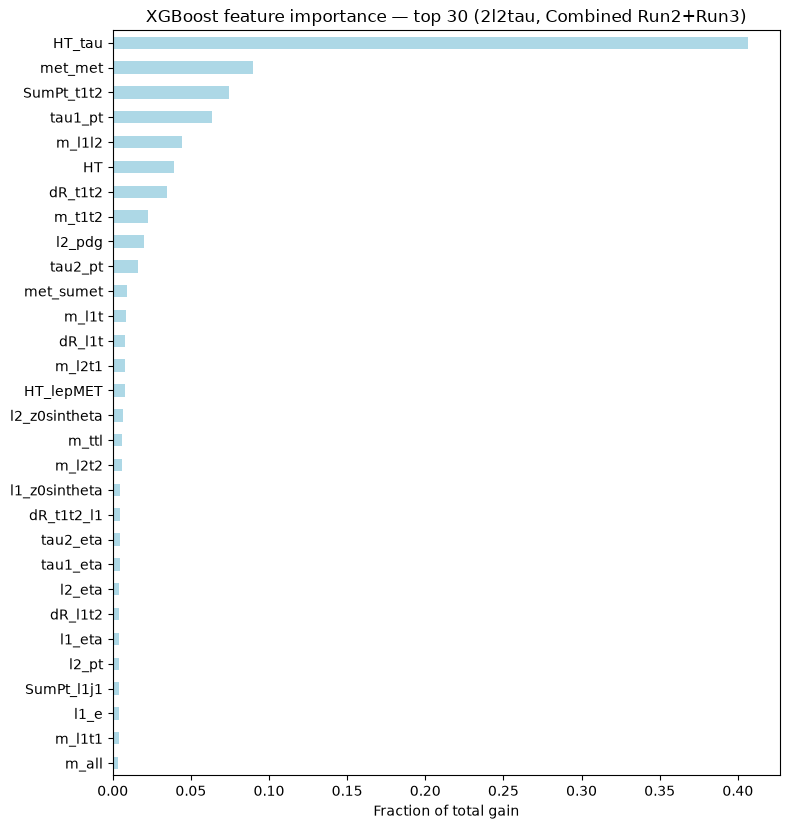

In [35]:
# ---- Baseline XGBoost + feature importance (Combined) -----------------------
model_comb, auc_train_comb, auc_val_comb = train_xgb_baseline(
    X_train_comb, y_train_comb, w_train_comb, X_val_comb, y_val_comb, w_val_comb, label="Combined baseline"
)

imp_comb = get_importance(model_comb, features_comb)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Combined Run2+Run3):")
print(imp_comb[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_comb['total_gain'] == 0).sum()} / {len(features_comb)}")

plot_importance_bar(imp_comb, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (2l2tau, Combined Run2+Run3)",
                     save_path=PLOTS_DIR_COMB / "CombinedBeforeCorrelation.png")


Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedCorrelationTop30.png


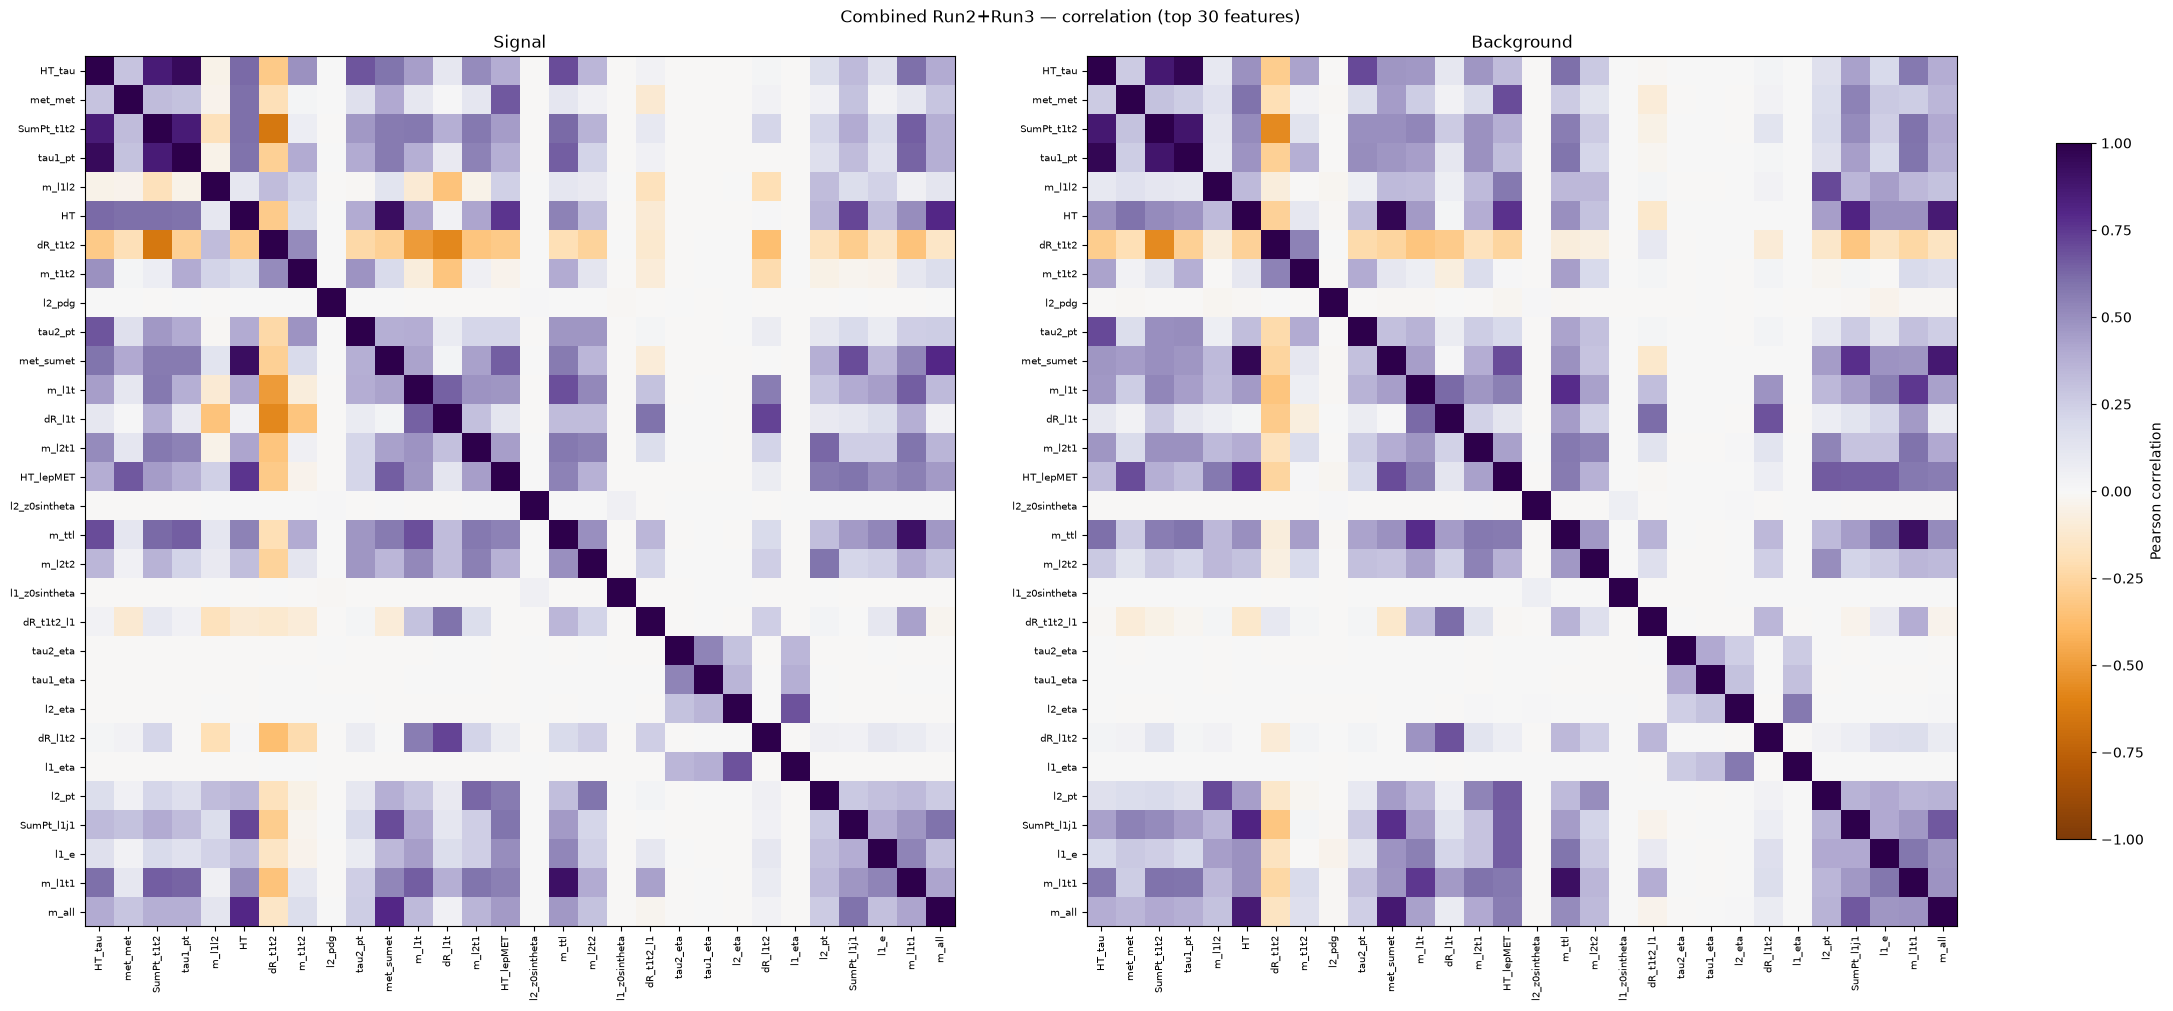

Pairs with |corr| > 0.50 (signal):
HT_tau      tau1_pt      0.944
HT          met_sumet    0.926
m_ttl       m_l1t1       0.908
SumPt_t1t2  tau1_pt      0.857
HT_tau      SumPt_t1t2   0.856
met_sumet   m_all        0.801
HT          m_all        0.799
            HT_lepMET    0.758
dR_l1t      dR_l1t2      0.722
HT          SumPt_l1j1   0.718
met_sumet   SumPt_l1j1   0.701
HT_tau      m_ttl        0.696
m_l1t       m_ttl        0.689
l2_eta      l1_eta       0.681
HT_tau      tau2_pt      0.674
met_met     HT_lepMET    0.668
tau1_pt     m_ttl        0.654
SumPt_t1t2  m_l1t1       0.654
met_sumet   HT_lepMET    0.653
m_l1t       m_l1t1       0.649
            dR_l1t       0.647
SumPt_t1t2  dR_t1t2      0.644
tau1_pt     m_l1t1       0.640
m_l2t1      l2_pt        0.627
HT_tau      HT           0.623
SumPt_t1t2  m_ttl        0.617
met_met     HT           0.608
SumPt_t1t2  HT           0.605
HT_tau      m_l1t1       0.603
tau1_pt     HT           0.601
SumPt_l1j1  m_all        0.599
dR_l

In [36]:
# ---- Correlation of the top features + pruning (Combined) -------------------
top_feats_comb = imp_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(data_comb, top_feats_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"Combined Run2+Run3 — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())

corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_COMB, dropped_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)


[Combined pruned] signal weight scale factor: 4284.8
[0]	validation_0-logloss:0.64820	validation_0-auc:0.89308
[50]	validation_0-logloss:0.25476	validation_0-auc:0.96751


[100]	validation_0-logloss:0.25287	validation_0-auc:0.96971
[150]	validation_0-logloss:0.25712	validation_0-auc:0.97027
[190]	validation_0-logloss:0.26015	validation_0-auc:0.97047
[Combined pruned] best_iteration=160 | weighted AUC: train=0.9869 val=0.9705

Comparison — full 79 features: val AUC = 0.9773 | pruned 20 features: val AUC = 0.9705
Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedAfterCorrelation.png


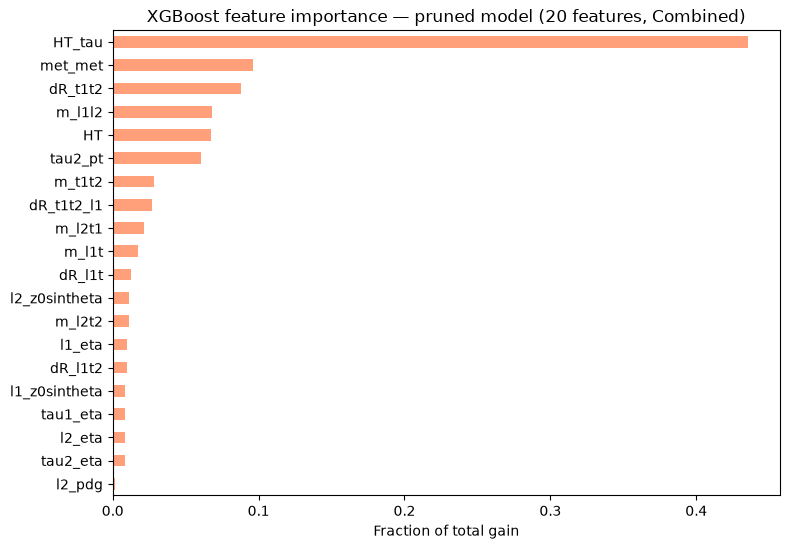

In [37]:
# ---- Retrain on the pruned feature set + re-check correlation (Combined) ---
model_comb_pruned, auc_train_comb_pruned, auc_val_comb_pruned = train_xgb_baseline(
    X_train_comb[PRUNED_FEATURES_COMB], y_train_comb, w_train_comb,
    X_val_comb[PRUNED_FEATURES_COMB], y_val_comb, w_val_comb, label="Combined pruned",
)

imp_comb_pruned = get_importance(model_comb_pruned, PRUNED_FEATURES_COMB)
print(f"\nComparison — full {len(features_comb)} features: val AUC = {auc_val_comb:.4f} | "
      f"pruned {len(PRUNED_FEATURES_COMB)} features: val AUC = {auc_val_comb_pruned:.4f}")

plot_importance_bar(
    imp_comb_pruned, top_n=len(PRUNED_FEATURES_COMB),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_COMB)} features, Combined)",
    color="lightsalmon",
    save_path=PLOTS_DIR_COMB / "CombinedAfterCorrelation.png",
)


### Top-15 further cut

Take the top 15 features from the pruned model's own ranking and retrain once
more, to see how much validation AUC is lost going from 20 → 15 features.


In [38]:
# ---- Retrain using only the top 15 features (Combined) ----------------------
TOP_15 = 15
TOP15_FEATURES_COMB = imp_comb_pruned.index[:TOP_15].tolist()
print(f"Top {TOP_15} features kept (from the 20-feature pruned model's own ranking):")
for i, feat in enumerate(TOP15_FEATURES_COMB, 1):
    print(f"  {i:2d}. {feat}")

model_comb_top15, auc_train_comb_top15, auc_val_comb_top15 = train_xgb_baseline(
    X_train_comb[TOP15_FEATURES_COMB], y_train_comb, w_train_comb,
    X_val_comb[TOP15_FEATURES_COMB], y_val_comb, w_val_comb, label="Combined top-15",
)

print(f"\nWeighted AUC (top {TOP_15} features):  val = {auc_val_comb_top15:.4f}")
print(f"Weighted AUC (pruned {len(PRUNED_FEATURES_COMB)} features): val = {auc_val_comb_pruned:.4f}")
print(f"Weighted AUC (full {len(features_comb)} features):    val = {auc_val_comb:.4f}")


Top 15 features kept (from the 20-feature pruned model's own ranking):
   1. HT_tau
   2. met_met
   3. dR_t1t2
   4. m_l1l2
   5. HT
   6. tau2_pt
   7. m_t1t2
   8. dR_t1t2_l1
   9. m_l2t1
  10. m_l1t
  11. dR_l1t
  12. l2_z0sintheta
  13. m_l2t2
  14. l1_eta
  15. dR_l1t2
[Combined top-15] signal weight scale factor: 4284.8
[0]	validation_0-logloss:0.63385	validation_0-auc:0.94340
[50]	validation_0-logloss:0.25581	validation_0-auc:0.96718
[100]	validation_0-logloss:0.25249	validation_0-auc:0.96950
[150]	validation_0-logloss:0.25707	validation_0-auc:0.96977
[172]	validation_0-logloss:0.26030	validation_0-auc:0.96973
[Combined top-15] best_iteration=142 | weighted AUC: train=0.9853 val=0.9699

Weighted AUC (top 15 features):  val = 0.9699
Weighted AUC (pruned 20 features): val = 0.9705
Weighted AUC (full 79 features):    val = 0.9773


Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedModelComparison.png


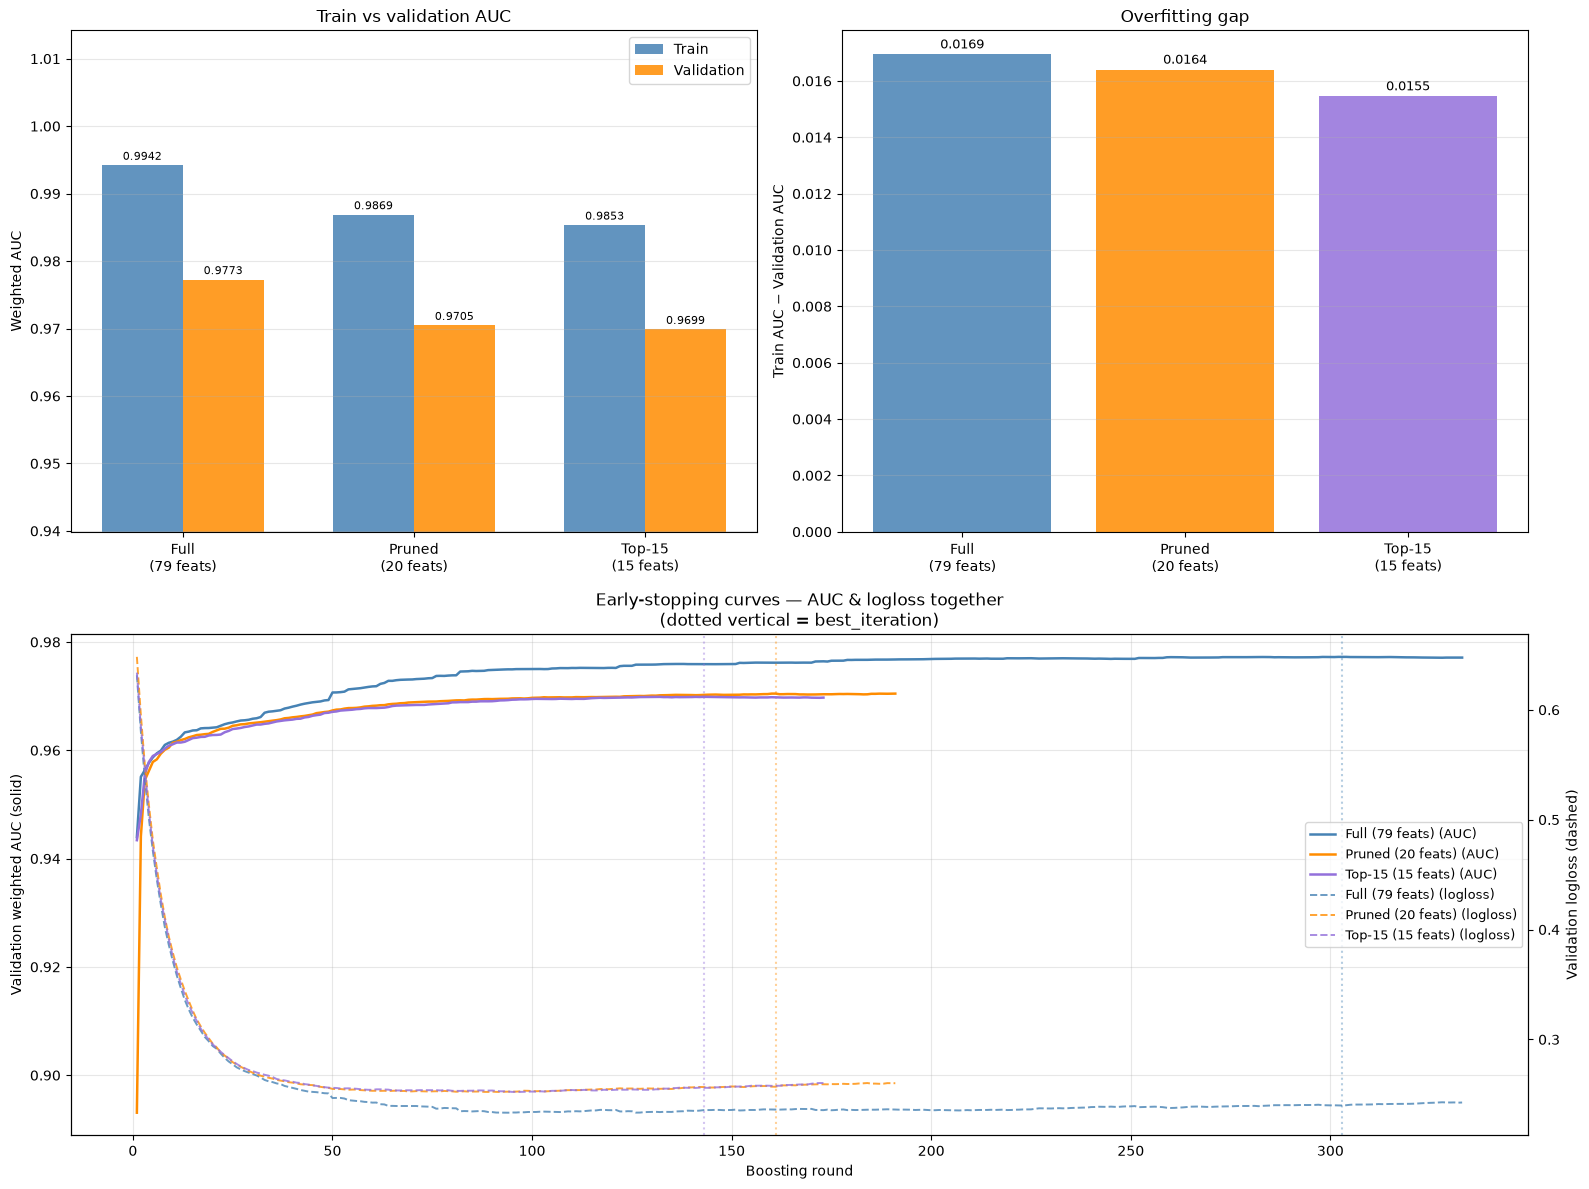

Model                #Features   Train AUC     Val AUC       Gap
Full                        79      0.9942      0.9773    0.0169
Pruned                      20      0.9869      0.9705    0.0164
Top-15                      15      0.9853      0.9699    0.0155


In [39]:
# ---- Model comparison — AUC & training curves (full vs pruned vs top-15) ---

model_names_comb = [f"Full\n({len(features_comb)} feats)", f"Pruned\n({len(PRUNED_FEATURES_COMB)} feats)",
                     f"Top-15\n({len(TOP15_FEATURES_COMB)} feats)"]
colors_comb = ["steelblue", "darkorange", "mediumpurple"]
train_aucs_comb = [auc_train_comb, auc_train_comb_pruned, auc_train_comb_top15]
val_aucs_comb = [auc_val_comb, auc_val_comb_pruned, auc_val_comb_top15]
models_fitted_comb = [model_comb, model_comb_pruned, model_comb_top15]

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)
ax_bars = fig.add_subplot(gs[0, 0])
ax_gap = fig.add_subplot(gs[0, 1])
ax_auc = fig.add_subplot(gs[1, :])   # wide combined panel, spans both columns

# --- Panel (0,0): train vs validation AUC, grouped bars --------------------
x = np.arange(len(model_names_comb))
width = 0.35
b1 = ax_bars.bar(x - width/2, train_aucs_comb, width, label="Train", color="steelblue", alpha=0.85)
b2 = ax_bars.bar(x + width/2, val_aucs_comb, width, label="Validation", color="darkorange", alpha=0.85)
for bars in (b1, b2):
    ax_bars.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax_bars.set_xticks(x)
ax_bars.set_xticklabels(model_names_comb)
ax_bars.set_ylabel("Weighted AUC")
ax_bars.set_ylim(min(val_aucs_comb) - 0.03, max(train_aucs_comb) + 0.02)
ax_bars.set_title("Train vs validation AUC")
ax_bars.legend()
ax_bars.grid(axis="y", alpha=0.3)

# --- Panel (0,1): overfitting gap (train - validation AUC) -----------------
gaps_comb = [t - v for t, v in zip(train_aucs_comb, val_aucs_comb)]
bars = ax_gap.bar(model_names_comb, gaps_comb, color=colors_comb, alpha=0.85)
ax_gap.bar_label(bars, fmt="%.4f", fontsize=9, padding=2)
ax_gap.set_ylabel("Train AUC − Validation AUC")
ax_gap.set_title("Overfitting gap")
ax_gap.grid(axis="y", alpha=0.3)

# --- Panel (1, :): validation AUC + logloss vs boosting round --------------
ax_loss = ax_auc.twinx()
for name, mdl, color in zip(model_names_comb, models_fitted_comb, colors_comb):
    label = name.replace("\n", " ")
    auc_curve = mdl.evals_result()["validation_0"]["auc"]
    loss_curve = mdl.evals_result()["validation_0"]["logloss"]
    rounds = np.arange(1, len(auc_curve) + 1)
    ax_auc.plot(rounds, auc_curve, color=color, linestyle="-", linewidth=1.8, label=f"{label} (AUC)")
    ax_loss.plot(rounds, loss_curve, color=color, linestyle="--", linewidth=1.4, alpha=0.8, label=f"{label} (logloss)")
    ax_auc.axvline(mdl.best_iteration + 1, color=color, linestyle=":", alpha=0.4)

ax_auc.set_xlabel("Boosting round")
ax_auc.set_ylabel("Validation weighted AUC (solid)")
ax_loss.set_ylabel("Validation logloss (dashed)")
ax_auc.set_title("Early-stopping curves — AUC & logloss together\n(dotted vertical = best_iteration)")
ax_auc.grid(alpha=0.3)

lines_auc, labels_auc = ax_auc.get_legend_handles_labels()
lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
ax_auc.legend(lines_auc + lines_loss, labels_auc + labels_loss, fontsize=9, loc="center right")

plt.tight_layout()
fig.savefig(PLOTS_DIR_COMB / "CombinedModelComparison.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_COMB / 'CombinedModelComparison.png'}")
plt.show()

print(f"{'Model':<20s}{'#Features':>10s}{'Train AUC':>12s}{'Val AUC':>12s}{'Gap':>10s}")
for name, feats, tr, va in zip(["Full", "Pruned", "Top-15"],
                                [features_comb, PRUNED_FEATURES_COMB, TOP15_FEATURES_COMB],
                                train_aucs_comb, val_aucs_comb):
    print(f"{name:<20s}{len(feats):>10d}{tr:>12.4f}{va:>12.4f}{tr - va:>10.4f}")


### Optuna tuning (Combined)


In [40]:
# ---- Optuna hyperparameter search (Combined) --------------------------------
OPTUNA_FEATURES_COMB = PRUNED_FEATURES_COMB.copy()

X_opt_comb = X_train_comb[OPTUNA_FEATURES_COMB].reset_index(drop=True)
y_opt_comb = y_train_comb.reset_index(drop=True).to_numpy()
w_opt_comb = np.abs(w_train_comb.reset_index(drop=True).to_numpy())

study_comb = run_optuna_search(
    X_opt_comb, y_opt_comb, w_opt_comb,
    n_trials=N_OPTUNA_TRIALS, n_folds=N_OPTUNA_FOLDS,
    base_n_estimators=800, study_name="xgb_2l2tau_combined",
)


/tmp/ipykernel_42855/2307537205.py:74: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_2l2tau_combined] completed trials: 15
[xgb_2l2tau_combined] best mean CV AUC: 0.97178
[xgb_2l2tau_combined] mean best iteration: 645
[xgb_2l2tau_combined] fold AUCs: [0.9714178983281996, 0.9727036278722199, 0.9712304503225854]
[xgb_2l2tau_combined] best parameters:
    learning_rate: 0.023231731978492907
    max_depth: 8
    min_child_weight: 43.70990468130503
    subsample: 0.9233589392465844
    colsample_bytree: 0.7218455076693483
    gamma: 0.48836057003191935
    reg_alpha: 0.2637333993381525
    reg_lambda: 1.5415527060141936


[Combined tuned] features=20 trees=645
[Combined tuned] weighted AUC: train=0.98871 val(holdout)=0.97147 (unweighted val=0.88783, overtrain gap=0.01724)
Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedOptunaDiagnostics.png


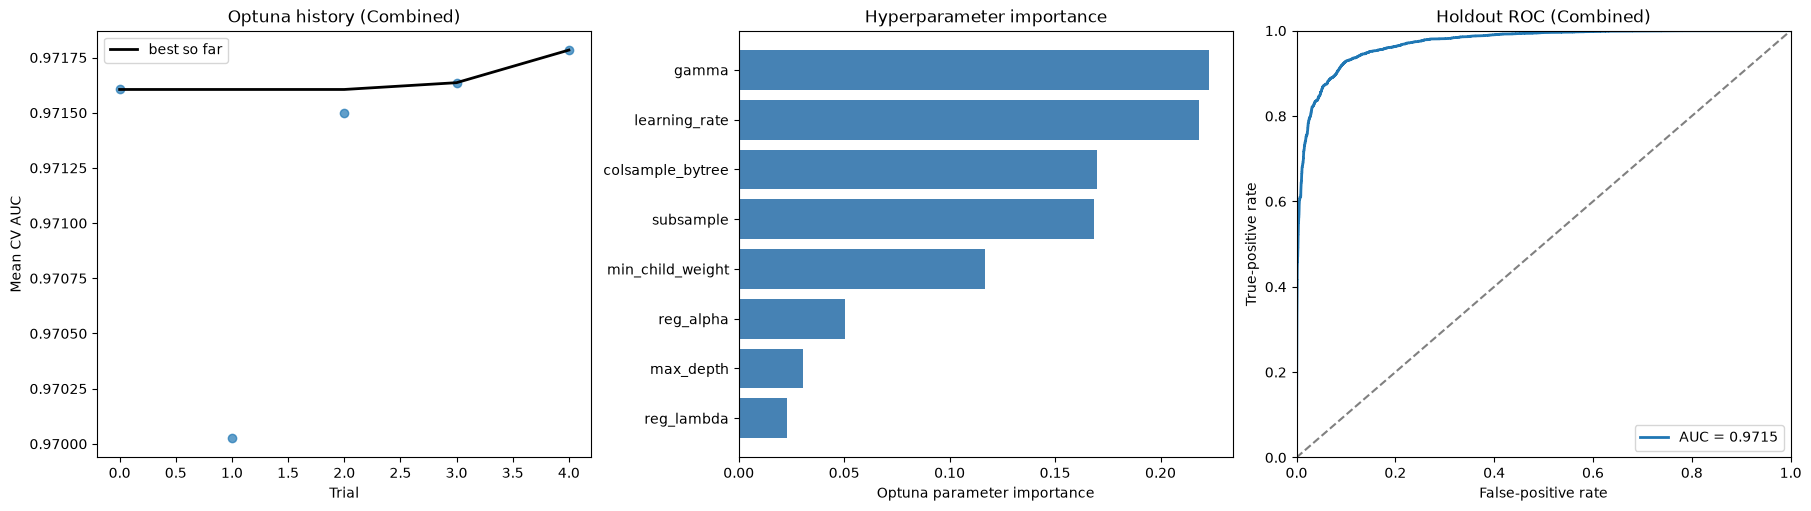

Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedAfterOptuna.png


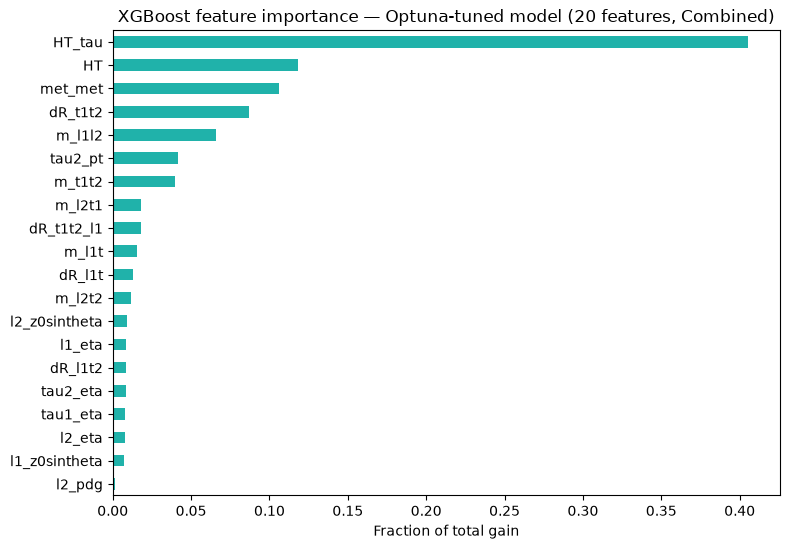

In [41]:
# ---- Final Optuna-tuned model + diagnostics (Combined) ----------------------
final_model_comb, auc_train_opt_comb, auc_val_opt_comb, pred_val_comb, w_val_abs_comb = train_final_tuned_model(
    study_comb, X_train_comb[OPTUNA_FEATURES_COMB], y_train_comb, w_train_comb,
    X_val_comb[OPTUNA_FEATURES_COMB], y_val_comb, w_val_comb, label="Combined tuned",
)

plot_optuna_diagnostics(study_comb, y_val_comb, pred_val_comb, w_val_abs_comb, auc_val_opt_comb, title_suffix="(Combined)",
                        save_path=PLOTS_DIR_COMB / "CombinedOptunaDiagnostics.png")

final_imp_comb = get_importance(final_model_comb, OPTUNA_FEATURES_COMB)
plot_importance_bar(
    final_imp_comb, top_n=len(OPTUNA_FEATURES_COMB),
    title=f"XGBoost feature importance — Optuna-tuned model ({len(OPTUNA_FEATURES_COMB)} features, Combined)",
    color="lightseagreen",
    save_path=PLOTS_DIR_COMB / "CombinedAfterOptuna.png",
)


In [42]:
# ---- Persist the Combined final model + feature list -------------------------
# BASE_DIR_COMB was already defined at the start of Section 5.
MODEL_PATH_COMB = BASE_DIR_COMB / "final_model_combined.json"
FEATURES_PATH_COMB = BASE_DIR_COMB / "optuna_features_combined.json"

final_model_comb.save_model(MODEL_PATH_COMB)
with open(FEATURES_PATH_COMB, "w") as f:
    json.dump(OPTUNA_FEATURES_COMB, f)

print(f"Saved Combined final model                   -> {MODEL_PATH_COMB}")
print(f"Saved Combined feature list (n={len(OPTUNA_FEATURES_COMB)}) -> {FEATURES_PATH_COMB}")


Saved Combined final model                   -> PPSSP_2026/2l2tau/combined/final_model_combined.json
Saved Combined feature list (n=20) -> PPSSP_2026/2l2tau/combined/optuna_features_combined.json


### Did the ranking change? Run 2-only vs Run 3-only vs Combined

Compare where each of the Combined track's tuned features lands in the Run
2-only and Run 3-only tuned rankings (Sections 3/4) — a large rank shift for
a feature would be a warning sign that it behaves inconsistently between
campaigns.


In [43]:
# ---- Rank comparison across the three tuned tracks --------------------------
combined_rank = {feat: i + 1 for i, feat in enumerate(final_imp_comb.index)}
run2_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r2.index)}
run3_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r3.index)}

rows = []
for feat in OPTUNA_FEATURES_COMB:
    rows.append({
        "feature": feat,
        "combined_rank": combined_rank.get(feat),
        "run2_only_rank": run2_rank.get(feat, "not kept"),
        "run3_only_rank": run3_rank.get(feat, "not kept"),
    })
rank_compare = pd.DataFrame(rows).set_index("feature")


print(f"Combined-track top-{len(OPTUNA_FEATURES_COMB)} features vs. their rank in the "
      f"Run2-only / Run3-only tuned models:")
print(rank_compare.to_string())

# Simple rank-shift summary (only where the feature survived pruning in both
# single-run tracks too)

comparable = rank_compare[
    pd.to_numeric(rank_compare["run2_only_rank"], errors="coerce").notna()
    & pd.to_numeric(rank_compare["run3_only_rank"], errors="coerce").notna()
].astype({"run2_only_rank": float, "run3_only_rank": float})


rank_shift = ((comparable["combined_rank"] - comparable["run2_only_rank"]).abs()
              + (comparable["combined_rank"] - comparable["run3_only_rank"]).abs()) / 2


if len(rank_shift):
    print(f"\nMean |rank shift| vs combined (averaged over Run2/Run3): {rank_shift.mean():.1f} positions")
    print(f"Max |rank shift|: {rank_shift.max():.0f} positions ({rank_shift.idxmax()})")


Combined-track top-20 features vs. their rank in the Run2-only / Run3-only tuned models:
               combined_rank run2_only_rank run3_only_rank
feature                                                   
HT_tau                     1       not kept              1
met_met                    3              3              3
m_l1l2                     5              5              5
HT                         2              2              2
dR_t1t2                    4              6              4
m_t1t2                     7              7              7
l2_pdg                    20             20             20
tau2_pt                    6              4              6
m_l1t                     10             12       not kept
dR_l1t                    11              9             10
m_l2t1                     8             11              8
l2_z0sintheta             13             17             13
m_l2t2                    12             16             14
l1_z0sintheta             

## 6. Run 2 vs Run 3 — Domain-Shift Check

A separate, lightweight XGBoost model whose only job is telling **Run 2**
signal events (ggF + VBF) apart from **Run 3** signal events. This is
completely independent from the signal-vs-background classifiers trained in
Sections 3-5 - nothing there is touched or reused as a model, only their
*feature list* is reused (the Combined track's tuned, decorrelated features,
persisted to disk in Section 5), so the test reflects exactly the variables
that would feed the final analysis.

**Label convention:** Run 2 = 0, Run 3 = 1. **Weights:** the raw `weights`
branch is used AS-IS (not `weight * weights`, unlike `w_phys` elsewhere) -
this test cares about the shape of the per-event generator weight, not the
physical yield.

**How to read the resulting AUC:** AUC ≈ 0.5 → the classifier can't tell the
runs apart → the feature distributions are effectively the same between Run 2
and Run 3. AUC well above 0.5 → a genuine distribution shift, and `AUC - 0.5`
is roughly its effect size.


In [44]:
# ---- Feature set to test for a Run2/Run3 shift ------------------------------
# Uses the Combined track's tuned, decorrelated feature set (persisted to
# disk in Section 5) - these are the features that would actually go into the
# final analysis, so this checks exactly the variables that matter. Loaded
# from disk (rather than reusing the in-memory variable) so this section can
# also be run on its own after a kernel restart.
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots_2l2tau")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)

FEATURES_PATH_DOMAIN = BASE_DIR_COMB / "optuna_features_combined.json"
with open(FEATURES_PATH_DOMAIN) as f:
    domain_features = json.load(f)

print(f"Loaded {len(domain_features)} features from {FEATURES_PATH_DOMAIN}:")
print(domain_features)

SIGNAL_FILES = {"signal_ggF": "signal_ggF.root", "signal_VBF": "signal_VBF.root"}
WEIGHT_BRANCH = "weights"   # raw per-event branch, used AS-IS as sample_weight

# Sanity check: confirm every feature exists in all four signal files
# (ggF + VBF, Run2 + Run3) before we try to read them.
common_domain = None
for base_dir in (BASE_DIR_R2, BASE_DIR_R3):
    for fname in SIGNAL_FILES.values():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common_domain = keys if common_domain is None else common_domain & keys
missing = [f for f in domain_features if f not in common_domain]
if missing:
    raise ValueError(f"Features missing from one or more signal files: {missing}")


Loaded 20 features from PPSSP_2026/2l2tau/combined/optuna_features_combined.json:
['HT_tau', 'met_met', 'm_l1l2', 'HT', 'dR_t1t2', 'm_t1t2', 'l2_pdg', 'tau2_pt', 'm_l1t', 'dR_l1t', 'm_l2t1', 'l2_z0sintheta', 'm_l2t2', 'l1_z0sintheta', 'dR_t1t2_l1', 'tau2_eta', 'tau1_eta', 'l2_eta', 'dR_l1t2', 'l1_eta']


In [45]:
# ---- Load Run2 + Run3 signal events (label: Run2=0, Run3=1) -----------------
frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_R2), (1, "Run 3", BASE_DIR_R3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        df["process"] = proc
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(domain_data)} events "
      f"(Run 2 = {(domain_data.run_label == 0).sum()}, Run 3 = {(domain_data.run_label == 1).sum()})")

# ---- Post-concat cleaning: constant features + sentinel -> NaN -------------
domain_data, domain_features = clean_data(domain_data, domain_features)

# ---- Sanity check: weight sums & negative-weight fractions ------------------
# Comparable total weight -> comparable effective normalization between runs.
# Negative weights are reported but NOT dropped (Sherpa NLO interference
# effects are physical, not a data-quality issue).
for run_label, run_name in [(0, "Run 2"), (1, "Run 3")]:
    subset = domain_data.loc[domain_data.run_label == run_label, WEIGHT_BRANCH]
    total_w = subset.sum()
    neg_frac = (subset < 0).mean()
    print(f"{run_name}: sum({WEIGHT_BRANCH}) = {total_w:12.4f} | "
          f"negative-weight fraction = {neg_frac:6.2%} | n_events = {len(subset)}")


Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection
Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection

Total: 137905 events (Run 2 = 37557, Run 3 = 100348)
Dropped 0 constant/empty features:
  []

20 final features
Run 2: sum(weights) =     871.9282 | negative-weight fraction =  5.24% | n_events = 37557
Run 3: sum(weights) =    2634.0020 | negative-weight fraction =  5.94% | n_events = 100348


In [46]:
# ---- Build training arrays ---------------------------------------------------

X = domain_data[domain_features]
y = domain_data["run_label"].to_numpy()
w_raw = domain_data[WEIGHT_BRANCH].to_numpy()   # raw branch, AS-IS
w_abs = np.abs(w_raw)

# --- Class balance ------------------------------------------------------------
# Run 2 and Run 3 can have different total weight (see sanity check above);
# rescale per-event weights so both runs contribute equal total weight,
# otherwise the AUC would partly reflect a normalization difference rather
# than a genuine shape difference (mirrors make_fit_weights, but keyed on
# run_label instead of label).

w_fit = w_abs.copy()
sum_r2, sum_r3 = w_fit[y == 0].sum(), w_fit[y == 1].sum()
w_fit[y == 1] *= sum_r2 / sum_r3
w_fit *= len(w_fit) / w_fit.sum()

print(f"Run2/Run3 total-weight ratio before balancing: {sum_r2 / sum_r3:.3f}")
print(f"Run2/Run3 total-weight ratio after balancing:  {w_fit[y == 0].sum() / w_fit[y == 1].sum():.3f}")


Run2/Run3 total-weight ratio before balancing: 0.330
Run2/Run3 total-weight ratio after balancing:  1.000


In [47]:
# ---- Stratified K-Fold cross-validation --------------------------------------
# AUC is computed ONLY on each held-out fold. IMPORTANT: no early stopping /
# eval_set here - that would let XGBoost pick best_iteration to maximize AUC
# on the exact fold being scored, an upward-biasing leak that matters a lot
# when the whole point is testing "is AUC ~ 0.5".

N_FOLDS_DOMAIN = 5
cv = StratifiedKFold(n_splits=N_FOLDS_DOMAIN, shuffle=True, random_state=RANDOM_STATE)

# Moved to the device ONCE here and reused below in the "final model" cell too.
Xd = to_device(X, USE_GPU)
yd = to_device(y, USE_GPU)

fold_aucs = []
for fold, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    domain_cv_params = dict(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    )
    if USE_GPU:
        domain_cv_params["device"] = "cuda"
    fold_model = xgb.XGBClassifier(**domain_cv_params)
    fold_model.fit(Xd[idx_tr], yd[idx_tr], sample_weight=to_device(w_fit[idx_tr], USE_GPU), verbose=False)
    pred = fold_model.predict_proba(Xd[idx_te])[:, 1]
    fold_auc = roc_auc_score(y[idx_te], pred, sample_weight=w_abs[idx_te])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS_DOMAIN}: weighted AUC = {fold_auc:.4f}")

fold_aucs = np.array(fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS_DOMAIN} folds: {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)")


Fold 1/5: weighted AUC = 0.5225
Fold 2/5: weighted AUC = 0.5071
Fold 3/5: weighted AUC = 0.5223
Fold 4/5: weighted AUC = 0.5232
Fold 5/5: weighted AUC = 0.5145

Mean weighted AUC across 5 folds: 0.5179 ± 0.0063
(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)


Held-out AUC of this single interpretation model: 0.5225 (compare to the 5-fold mean above)
Saved plot -> run2_vs_run3_plots_2l2tau/DomainShiftSignalImportance.png


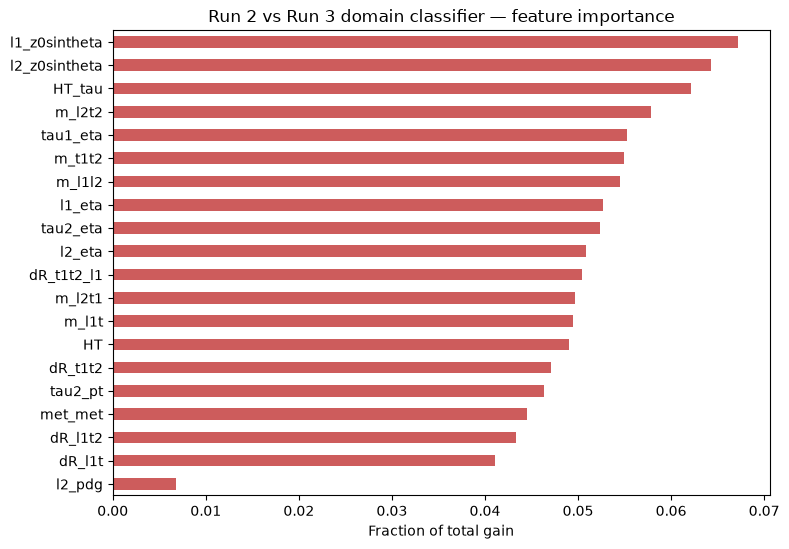

In [48]:
# ---- Final model (single split) + feature importance -------------------------
# The k-fold result above is the AUC estimate to quote - this single model is
# only to get one clean feature-importance / SHAP picture.
train_idx, test_idx = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y))

domain_final_params = dict(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)

if USE_GPU:
    domain_final_params["device"] = "cuda"

final_domain_model = xgb.XGBClassifier(**domain_final_params)
final_domain_model.fit(Xd[train_idx], yd[train_idx], sample_weight=to_device(w_fit[train_idx], USE_GPU), verbose=False)
final_domain_model.get_booster().feature_names = domain_features  # restore names lost by fitting on raw arrays

pred_test = final_domain_model.predict_proba(Xd[test_idx])[:, 1]
auc_test_domain = roc_auc_score(y[test_idx], pred_test, sample_weight=w_abs[test_idx])

print(f"Held-out AUC of this single interpretation model: {auc_test_domain:.4f} "
      f"(compare to the {N_FOLDS_DOMAIN}-fold mean above)")

imp_domain = get_importance(final_domain_model, domain_features)
plot_importance_bar(imp_domain, top_n=len(domain_features),
                     title="Run 2 vs Run 3 domain classifier — feature importance", color="indianred",
                     save_path=PLOTS_DIR_DOMAIN / "DomainShiftSignalImportance.png")


Saved plot -> run2_vs_run3_plots_2l2tau/DomainShiftSHAPSummary.png


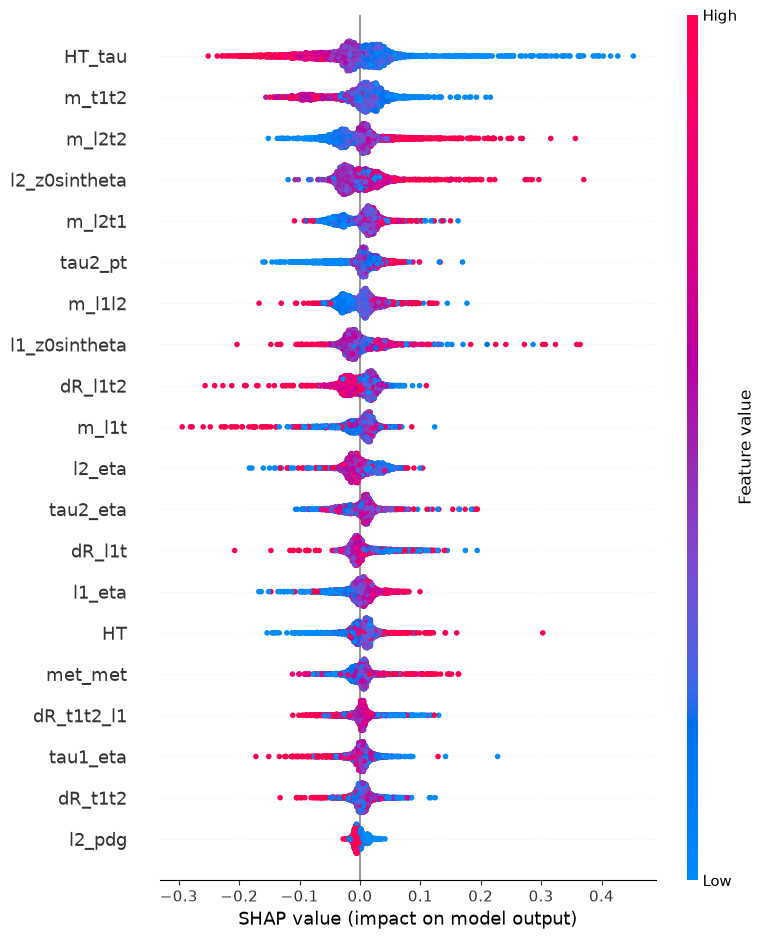

In [49]:
# ---- SHAP values --------------------
# Subsample for speed; TreeExplainer is exact for tree models, so a moderate
# sample is enough to see the global pattern.

try:
    import shap

    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
    X_shap = X.iloc[sample_idx]

    explainer = shap.TreeExplainer(final_domain_model)
    shap_values = explainer.shap_values(X_shap)
    shap.summary_plot(shap_values, X_shap, max_display=20, show=False)

    shap_save_path = PLOTS_DIR_DOMAIN / "DomainShiftSHAPSummary.png"
    shap_save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.gcf().savefig(shap_save_path, dpi=150, bbox_inches="tight")
    print(f"Saved plot -> {shap_save_path}")
    plt.show()
except ImportError:
    print("`shap` is not installed - skip this cell or `pip install shap` to see per-feature SHAP values.")


### All-processes scan

Repeat the same two-sample test independently for **every** simulated process
(not just the combined signal), to see whether Run2/Run3 differences are
localized to specific backgrounds or general across the production. Same
features, preselection and weight handling as above - just looped over every
ROOT file in `FILES` (Section 1).

Outputs: `run2_vs_run3_auc_summary_2l2tau.csv` (one row per process) and one
`run2_vs_run3_plots_2l2tau/<process>_importance.png` per process.


In [50]:
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots_2l2tau")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
RESULTS_CSV_DOMAIN = Path("run2_vs_run3_auc_summary_2l2tau.csv")


def run_two_sample_test(process_name, fname, features=domain_features, n_folds=3,
                         n_estimators=200, plots_dir=PLOTS_DIR_DOMAIN, use_gpu=USE_GPU):
    """Run2-vs-Run3 domain classifier for a single process (one ROOT file per
    run). Saves a feature-importance PNG and returns a summary dict. Lighter
    hyperparameters than the signal-only test above since this runs once per
    process - it's a scan, not the final result. No early stopping here
    either, for the same leakage reasons as the k-fold loop above.
    """
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_R2), (1, BASE_DIR_R3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)

    # Sentinel -> NaN only (no constant-feature dropping - every process must
    # keep the exact same feature set so results stay comparable).
    for feat in features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())

    X_proc = data[features]
    y_proc = data["run_label"].to_numpy()
    w_raw_proc = data[WEIGHT_BRANCH].to_numpy()
    w_abs_proc = np.abs(w_raw_proc)

    sum_w_r2 = w_raw_proc[y_proc == 0].sum()
    sum_w_r3 = w_raw_proc[y_proc == 1].sum()
    neg_frac_r2 = (w_raw_proc[y_proc == 0] < 0).mean() if n_r2 else np.nan
    neg_frac_r3 = (w_raw_proc[y_proc == 1] < 0).mean() if n_r3 else np.nan

    w_fit_proc = w_abs_proc.copy()
    sum_abs_r2, sum_abs_r3 = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_abs_r2 > 0 and sum_abs_r3 > 0:
        w_fit_proc[y_proc == 1] *= sum_abs_r2 / sum_abs_r3
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    Xd_proc = to_device(X_proc, use_gpu)
    yd_proc = to_device(y_proc, use_gpu)

    def make_params():
        params = dict(
            n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
        )
        if use_gpu:
            params["device"] = "cuda"
        return params

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fold_model = xgb.XGBClassifier(**make_params())
            fold_model.fit(Xd_proc[idx_tr], yd_proc[idx_tr],
                            sample_weight=to_device(w_fit_proc[idx_tr], use_gpu), verbose=False)
            pred = fold_model.predict_proba(Xd_proc[idx_te])[:, 1]
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc = float(fold_aucs.std()) if len(fold_aucs) else np.nan

    final = xgb.XGBClassifier(**make_params())
    final.fit(Xd_proc, yd_proc, sample_weight=to_device(w_fit_proc, use_gpu), verbose=False)
    final.get_booster().feature_names = features
    imp_proc = get_importance(final, features)

    fig, ax = plt.subplots(figsize=(8, 8))
    imp_proc["gain_frac"][::-1].plot.barh(ax=ax, color="teal")
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(f"Run 2 vs Run 3 — {process_name} — feature importance")
    plt.tight_layout()
    fig.savefig(plots_dir / f"{process_name}_importance.png", dpi=150)
    plt.close(fig)

    # A suspiciously high AUC dominated by one variable can be an artifact of
    # that variable's NaN *fraction* differing between runs (not its value) -
    # track that here so it can be sanity-checked before trusting the result.
    
    top_feature = imp_proc.index[0] if len(imp_proc) else None
    if top_feature is not None:
        nan_frac_r2 = data.loc[data.run_label == 0, top_feature].isna().mean()
        nan_frac_r3 = data.loc[data.run_label == 1, top_feature].isna().mean()
    else:
        nan_frac_r2 = nan_frac_r3 = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds) | "
          f"top feature = {top_feature} (NaN frac Run2={nan_frac_r2:.1%}, Run3={nan_frac_r3:.1%})")

    return {
        "process": process_name, "n_run2": n_r2, "n_run3": n_r3,
        "sum_weights_run2": sum_w_r2, "sum_weights_run3": sum_w_r3,
        "neg_weight_frac_run2": neg_frac_r2, "neg_weight_frac_run3": neg_frac_r3,
        "n_folds": n_splits, "mean_auc": mean_auc, "std_auc": std_auc,
        "top_feature": top_feature,
        "top_feature_gain_frac": imp_proc["gain_frac"].iloc[0] if len(imp_proc) else np.nan,
        "top_feature_nan_frac_run2": nan_frac_r2, "top_feature_nan_frac_run3": nan_frac_r3,
    }


In [51]:
# ---- Run the scan over every process and export the summary ----------------
results = [run_two_sample_test(proc, fname) for proc, (fname, _label) in FILES.items()]

results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV_DOMAIN, index=False)

print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV_DOMAIN}")
print(f"Saved {len(FILES)} feature-importance PNGs -> {PLOTS_DIR_DOMAIN}/")
results_df


signal_ggF  : Run2 =   31959 | Run3 =   96909 | weighted AUC = 0.5177 ± 0.0009 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)
signal_VBF  : Run2 =    5598 | Run3 =    3439 | weighted AUC = 0.4880 ± 0.0050 (3 folds) | top feature = l1_z0sintheta (NaN frac Run2=0.0%, Run3=0.0%)
Diboson     : Run2 =   36877 | Run3 =   82336 | weighted AUC = 0.5456 ± 0.0005 (3 folds) | top feature = HT (NaN frac Run2=0.0%, Run3=0.0%)
Zjets       : Run2 =    7746 | Run3 =   12919 | weighted AUC = 0.5380 ± 0.0183 (3 folds) | top feature = HT (NaN frac Run2=0.0%, Run3=0.0%)
Wjets       : Run2 =      67 | Run3 =      51 | weighted AUC = 0.3480 ± 0.0946 (3 folds) | top feature = dR_l1t2 (NaN frac Run2=0.0%, Run3=0.0%)
ttbar       : Run2 =     331 | Run3 =    3276 | weighted AUC = 0.4968 ± 0.0117 (3 folds) | top feature = m_l2t2 (NaN frac Run2=0.0%, Run3=0.0%)
tops        : Run2 =    3832 | Run3 =   11065 | weighted AUC = 0.5104 ± 0.0281 (3 folds) | top feature = dR_l1t2 (NaN frac Run2=0.0%, Ru

,process,n_run2,n_run3,sum_weights_run2,sum_weights_run3,neg_weight_frac_run2,neg_weight_frac_run3,n_folds,mean_auc,std_auc,top_feature,top_feature_gain_frac,top_feature_nan_frac_run2,top_feature_nan_frac_run3
0,SingleH,2946,3240,"3,287.662","20,399.010",0.004,0.005,3,0.669,0.008,m_l1l2,0.133,0.000,0.000
1,VVV,3593,13941,56.099,"28,662.676",0.003,0.010,3,0.613,0.017,HT_tau,0.147,0.000,0.000
2,Vgamma,2019,2366,"3,085,372,928.000","4,357,021,184.000",0.078,0.081,3,0.558,0.026,dR_t1t2,0.068,0.000,0.000
3,Diboson,36877,82336,"1,200,979,328.000","2,756,951,552.000",0.089,0.091,3,0.546,0.001,HT,0.091,0.000,0.000
4,Zjets,7746,12919,"23,516,846,080.000","56,472,010,752.000",0.158,0.155,3,0.538,0.018,HT,0.103,0.000,0.000
5,signal_ggF,31959,96909,864.790,"2,629.576",0.061,0.061,3,0.518,0.001,HT_tau,0.072,0.000,0.000
6,tops,3832,11065,"150,095.094","633,628.188",0.311,0.287,3,0.510,0.028,dR_l1t2,0.076,0.000,0.000
7,ttbar,331,3276,"244,279.250","312,398.281",0.003,0.003,3,0.497,0.012,m_l2t2,0.069,0.000,0.000
8,signal_VBF,5598,3439,7.138,4.426,0.001,0.002,3,0.488,0.005,l1_z0sintheta,0.072,0.000,0.000
9,Wjets,67,51,"1,189,386,240.000","174,232,768.000",0.104,0.157,3,0.348,0.095,dR_l1t2,0.172,0.000,0.000


### Diagnostic: Run 2 vs Run 3 shape overlay (SingleH `m_l1l2`, VVV `HT_tau`)

The per-process scan above flagged **SingleH** (AUC = 0.646, top feature
`m_l1l2` at ~14% of gain) and **VVV** (AUC = 0.637, top feature `HT_tau` at
~16% of gain) as the two processes with a real, single-feature-concentrated
Run2/Run3 difference — as opposed to Wjets' sub-0.5 result, which is just
small-sample noise from ~100 total events. This overlays the Run 2 vs Run 3
shape of exactly those two (process, feature) pairs directly, using the same
raw `weights` branch (AS-IS, not `w_phys`) and sentinel-masking convention as
the rest of this section.


SingleH Run 2: 2946 / 2946 events with valid m_l1l2
SingleH Run 3: 3240 / 3240 events with valid m_l1l2
VVV Run 2: 3593 / 3593 events with valid HT_tau
VVV Run 3: 13941 / 13941 events with valid HT_tau


Saved plot -> run2_vs_run3_plots_2l2tau/SingleH_VVV_ShapeOverlay.png


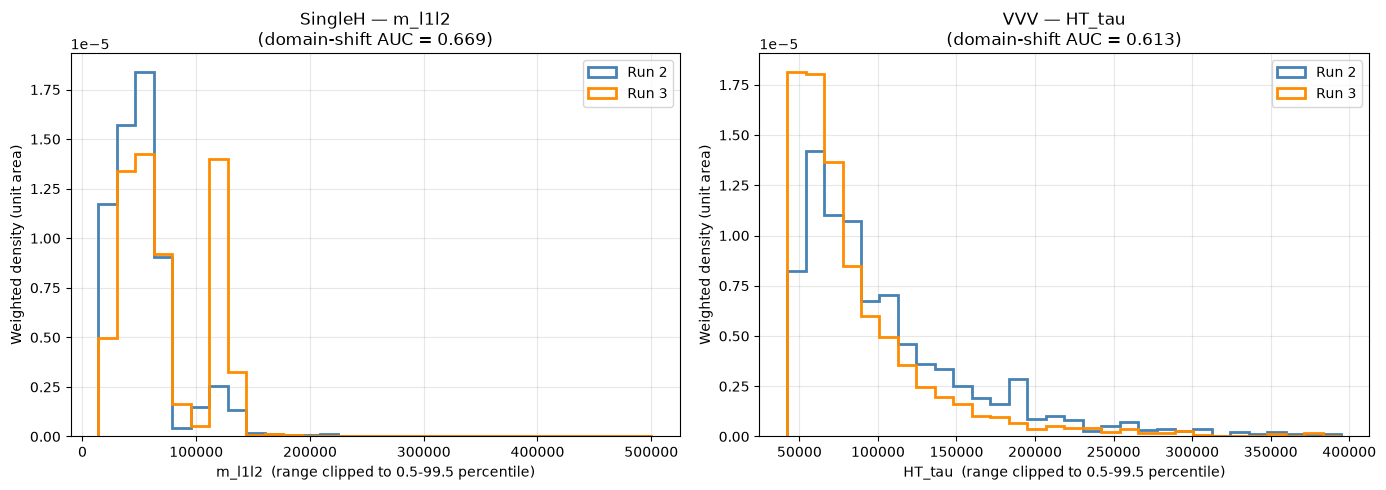

In [52]:
# ---- Run2 vs Run3 shape overlay for the two flagged processes --------------
# Same raw-`weights`-AS-IS convention as the rest of Section 6, and the same
# sentinel-masking (< -100 -> NaN, dropped here) as clean_data. Reads
# `results_df`/`WEIGHT_BRANCH`/`PLOTS_DIR_DOMAIN` from disk/locals instead of
# relying on earlier-cell state, so this cell can also run standalone after a
# kernel restart.

WEIGHT_BRANCH = "weights"
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots_2l2tau")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
results_df = pd.read_csv("run2_vs_run3_auc_summary_2l2tau.csv")

OVERLAY_TARGETS = [
    ("SingleH", "singleH.root", "m_l1l2"),
    ("VVV", "VVV.root", "HT_tau"),
]

fig, axes = plt.subplots(1, len(OVERLAY_TARGETS), figsize=(7 * len(OVERLAY_TARGETS), 5))
axes = np.atleast_1d(axes)

for ax, (proc_name, fname, feat) in zip(axes, OVERLAY_TARGETS):
    run_arrays = {}
    for run_label, run_name, base_dir in [(2, "Run 2", BASE_DIR_R2), (3, "Run 3", BASE_DIR_R3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays([feat, WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        vals = df[feat].mask(df[feat] < -100)  # sentinel -> NaN
        mask = vals.notna()
        run_arrays[run_label] = (vals[mask].to_numpy(), np.abs(df.loc[mask, WEIGHT_BRANCH].to_numpy()))
        print(f"{proc_name} {run_name}: {int(mask.sum())} / {len(df)} events with valid {feat}")

    # Clip the bin range to the 0.5-99.5 percentile of the pooled data - a
    # handful of long-tail outlier events otherwise stretch the axis so far
    # that the bulk of the distribution collapses into a couple of bins.
    
    all_vals = np.concatenate([v for v, w in run_arrays.values()])
    lo, hi = np.percentile(all_vals, [0.5, 99.5])
    bins = np.linspace(lo, hi, 31)

    for run_label, run_name, color in [(2, "Run 2", "steelblue"), (3, "Run 3", "darkorange")]:
        vals, weights = run_arrays[run_label]
        ax.hist(vals, bins=bins, weights=weights, density=True, histtype="step",
                linewidth=2, color=color, label=run_name)

    ax.set_xlabel(f"{feat}  (range clipped to 0.5-99.5 percentile)")
    ax.set_ylabel("Weighted density (unit area)")
    ax.set_title(f"{proc_name} — {feat}\n(domain-shift AUC = "
                 f"{results_df.set_index('process').loc[proc_name, 'mean_auc']:.3f})")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
overlay_path = PLOTS_DIR_DOMAIN / "SingleH_VVV_ShapeOverlay.png"
fig.savefig(overlay_path, dpi=150)
print(f"Saved plot -> {overlay_path}")
plt.show()


## 7. Summary


Validation weighted AUC by track and feature-selection stage:
          baseline  pruned  tuned
track                            
Run 2       0.9707  0.9657 0.9663
Run 3       0.9790  0.9716 0.9728
Combined    0.9773  0.9705 0.9715
Saved plot -> PPSSP_2026/2l2tau/summary_plots/AUCSummaryByTrack.png


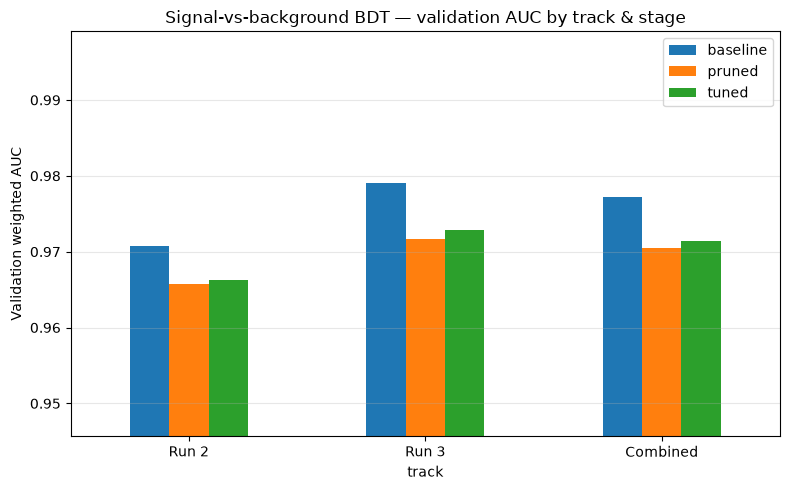


Run2 vs Run3 domain-shift check (signal, combined-track features): mean weighted AUC = 0.5179 ± 0.0063
(closer to 0.5 = the two campaigns agree better on the features that matter)

Per-process domain-shift AUCs (highest first):
   process  mean_auc  std_auc   top_feature
   SingleH     0.669    0.008        m_l1l2
       VVV     0.613    0.017        HT_tau
    Vgamma     0.558    0.026       dR_t1t2
   Diboson     0.546    0.001            HT
     Zjets     0.538    0.018            HT
signal_ggF     0.518    0.001        HT_tau
      tops     0.510    0.028       dR_l1t2
     ttbar     0.497    0.012        m_l2t2
signal_VBF     0.488    0.005 l1_z0sintheta
     Wjets     0.348    0.095       dR_l1t2


In [53]:
# ---- Consolidated AUC comparison across all three tracks --------------------

PLOTS_DIR_SUMMARY = Path("PPSSP_2026/2l2tau/summary_plots")
PLOTS_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)

summary_rows = [
    {"track": "Run 2",    "baseline": auc_val_r2,   "pruned": auc_val_r2_pruned,   "tuned": auc_val_opt_r2},
    {"track": "Run 3",    "baseline": auc_val_r3,   "pruned": auc_val_r3_pruned,   "tuned": auc_val_opt_r3},
    {"track": "Combined", "baseline": auc_val_comb, "pruned": auc_val_comb_pruned, "tuned": auc_val_opt_comb},
]

summary_df = pd.DataFrame(summary_rows).set_index("track")
print("Validation weighted AUC by track and feature-selection stage:")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(8, 5))
summary_df.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Validation weighted AUC")
ax.set_title("Signal-vs-background BDT — validation AUC by track & stage")
ax.set_ylim(summary_df.values.min() - 0.02, summary_df.values.max() + 0.02)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

summary_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryByTrack.png"

fig.savefig(summary_plot_path, dpi=150)
print(f"Saved plot -> {summary_plot_path}")
plt.show()

print(f"\nRun2 vs Run3 domain-shift check (signal, combined-track features): "
      f"mean weighted AUC = {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(closer to 0.5 = the two campaigns agree better on the features that matter)")
print("\nPer-process domain-shift AUCs (highest first):")
print(results_df[["process", "mean_auc", "std_auc", "top_feature"]].to_string(index=False))


### Files written to disk

| Path | Contents |
| --- | --- |
| `PPSSP_2026/2l2tau/run2/final_model_run2.json` | Run-2 tuned XGBoost model |
| `PPSSP_2026/2l2tau/run2/optuna_features_run2.json` | Run-2 tuned feature list |
| `PPSSP_2026/2l2tau/run2/splits/{train,val}.root` | Run-2 train/val split |
| `PPSSP_2026/2l2tau/run2/plots/*.png` | Run-2 diagnostic plots (importance, correlation, Optuna) |
| `PPSSP_2026/2l2tau/run3/final_model_run3.json` | Run-3 tuned XGBoost model |
| `PPSSP_2026/2l2tau/run3/optuna_features_run3.json` | Run-3 tuned feature list |
| `PPSSP_2026/2l2tau/run3/splits/{train,val}.root` | Run-3 train/val split |
| `PPSSP_2026/2l2tau/run3/plots/*.png` | Run-3 diagnostic plots (importance, correlation, Optuna) |
| `PPSSP_2026/2l2tau/combined/final_model_combined.json` | Combined tuned XGBoost model |
| `PPSSP_2026/2l2tau/combined/optuna_features_combined.json` | Combined tuned feature list |
| `PPSSP_2026/2l2tau/combined/plots/*.png` | Combined diagnostic plots (importance, correlation, Optuna, model comparison) |
| `run2_vs_run3_auc_summary_2l2tau.csv` | Per-process Run2/Run3 domain-shift AUC |
| `run2_vs_run3_plots_2l2tau/*.png` | Signal domain-shift importance/SHAP plots + per-process feature-importance plots |
| `PPSSP_2026/2l2tau/summary_plots/AUCSummaryByTrack.png` | Consolidated AUC comparison across tracks |
